# Liver Patient Disease Prediction — Dataset Pre-Modeling Audit & EDA
### Indian Liver Patient Dataset (ILPD) · Research-grade audit notebook

**Goal of this notebook:** understand the data deeply *before* modeling, and turn every finding into a concrete, leakage-free design decision for the final prediction framework (preprocessing → feature engineering → feature selection → balancing → model family → evaluation protocol).





## Section 1 — Environment Setup
Imports, optional-library handling (installed only if missing), reproducibility seeds and plotting defaults.

In [1]:
# ============================================================
# Section 1: Environment Setup
# ============================================================

# 1.1 Standard library
import os, re, sys, json, math, random, warnings, importlib, subprocess
from collections import OrderedDict
from functools import partial

# 1.2 Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# 1.3 Optional-library importer: installs a package only if it is missing (needs Internet ON in Kaggle)
def safe_import(module_name, pip_name=None, install=True):
    try:
        return importlib.import_module(module_name)
    except ImportError:
        if not install:
            return None
        try:
            print(f"[INFO] Installing {pip_name or module_name} ...")
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or module_name],
                           check=True, timeout=600, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            importlib.invalidate_caches()
            return importlib.import_module(module_name)
        except Exception as exc:
            print(f"[WARN] {pip_name or module_name} unavailable ({type(exc).__name__}); dependent steps will be skipped.")
            return None

# BorutaPy (older releases) references NumPy aliases removed in NumPy >= 1.24; restore them first
for _alias, _typ in [("int", int), ("float", float), ("bool", bool), ("object", object)]:
    if not hasattr(np, _alias):
        setattr(np, _alias, _typ)

xgb      = safe_import("xgboost")
lgb      = safe_import("lightgbm")
cb       = safe_import("catboost")
imblearn = safe_import("imblearn", "imbalanced-learn")
shap     = safe_import("shap")
boruta   = safe_import("boruta", "Boruta")

# 1.4 scikit-learn
import sklearn
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_validate, cross_val_predict)
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer, FunctionTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (enables IterativeImputer)
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, LinearRegression, BayesianRidge
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier, ExtraTreesRegressor,
                              VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif, f_classif, chi2, RFECV, SelectKBest
from sklearn.inspection import permutation_importance
from sklearn.metrics import (make_scorer, recall_score, f1_score, roc_auc_score, average_precision_score,
                             balanced_accuracy_score, matthews_corrcoef, confusion_matrix, roc_curve,
                             precision_recall_curve, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline as SkPipeline
set_config(display="diagram")

if imblearn is not None:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
    from imblearn.combine import SMOTEENN, SMOTETomek
    from imblearn.under_sampling import RandomUnderSampler
    Pipeline = ImbPipeline          # supports resampling steps that act only on training folds
else:
    Pipeline = SkPipeline

# 1.5 Reproducibility
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
set_seed()
N_JOBS = -1

# 1.6 Output folders and plotting style
OUTPUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "axes.titleweight": "bold"})

def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), bbox_inches="tight")

AUDIT = OrderedDict()   # collects findings for the final research summary (Section 14)

print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | sklearn {sklearn.__version__}")
for _name, _mod in [("xgboost", xgb), ("lightgbm", lgb), ("catboost", cb), ("imbalanced-learn", imblearn),
                    ("shap", shap), ("boruta", boruta)]:
    print(f"  {_name:<17}: {getattr(_mod, '__version__', 'available') if _mod else 'NOT available'}")

Python 3.12.13 | numpy 2.0.2 | pandas 2.3.3 | sklearn 1.6.1
  xgboost          : 3.2.0
  lightgbm         : 4.6.0
  catboost         : 1.2.10
  imbalanced-learn : 0.14.1
  shap             : 0.51.0
  boruta           : available


## Section 2 — Dataset Loading
The directory is scanned; the most plausible data file is chosen automatically (keyword + format + size). Headerless versions of ILPD (the original UCI file has no header) are detected and handled.

In [2]:
# ============================================================
# Section 2: Dataset Loading
# ============================================================
DATA_DIR = "/kaggle/input/datasets/jeevannagaraj/indian-liver-patient-dataset"
SUPPORTED_EXT = (".csv", ".tsv", ".txt", ".data", ".xlsx", ".xls")
ILPD_STD_NAMES = ["Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin", "Alkaline_Phosphatase",
                  "ALT", "AST", "Total_Proteins", "Albumin", "AG_Ratio", "Target"]

# 2.1 Explore the directory
def show_tree(root, max_entries=100):
    print(f"Directory tree: {root}")
    count = 0
    for dirpath, _, filenames in os.walk(root):
        depth = dirpath[len(root):].count(os.sep)
        print("    " * depth + f"[{os.path.basename(dirpath) or dirpath}]")
        for f in sorted(filenames):
            size_kb = os.path.getsize(os.path.join(dirpath, f)) / 1024
            print("    " * (depth + 1) + f"{f}  ({size_kb:,.1f} KB)")
            count += 1
            if count >= max_entries:
                print("    ... (truncated)")
                return

def discover_files(root):
    found = []
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.lower().endswith(SUPPORTED_EXT):
                found.append(os.path.join(dirpath, f))
    return sorted(found)

def choose_data_file(files):
    def score(path):
        name = os.path.basename(path).lower()
        keyword = any(k in name for k in ("liver", "ilpd", "patient"))
        tabular = name.endswith((".csv", ".xlsx", ".xls", ".data"))
        return (int(keyword), int(tabular), os.path.getsize(path))
    return max(files, key=score)

if os.path.isdir(DATA_DIR):
    show_tree(DATA_DIR)
    candidate_files = discover_files(DATA_DIR)
else:
    print(f"[WARN] {DATA_DIR} not found; searching /kaggle/input instead.")
    candidate_files = discover_files("/kaggle/input") if os.path.isdir("/kaggle/input") else []
    liver_like = [f for f in candidate_files if any(k in f.lower() for k in ("liver", "ilpd"))]
    candidate_files = liver_like or candidate_files

if not candidate_files:
    raise FileNotFoundError("No tabular data file found. Attach the ILPD dataset via 'Add Input'.")

print("\nCandidate data files:")
for f in candidate_files:
    print("  -", f)
DATA_PATH = choose_data_file(candidate_files)
print(f"\nSelected file: {DATA_PATH}")

Directory tree: /kaggle/input/datasets/jeevannagaraj/indian-liver-patient-dataset
[indian-liver-patient-dataset]
    Indian Liver Patient Dataset (ILPD).csv  (23.3 KB)

Candidate data files:
  - /kaggle/input/datasets/jeevannagaraj/indian-liver-patient-dataset/Indian Liver Patient Dataset (ILPD).csv

Selected file: /kaggle/input/datasets/jeevannagaraj/indian-liver-patient-dataset/Indian Liver Patient Dataset (ILPD).csv


In [3]:
# 2.2 Robust reader: auto-detects delimiter; detects a missing header row
def read_any(path, header="infer"):
    ext = os.path.splitext(path)[1].lower()
    if ext in (".xlsx", ".xls"):
        return pd.read_excel(path, header=0 if header == "infer" else None)
    try:
        return pd.read_csv(path, sep=None, engine="python", header=header)
    except Exception:
        return pd.read_csv(path, header=header)

def looks_headerless(frame):
    def is_number(x):
        try:
            float(str(x))
            return True
        except ValueError:
            return False
    return sum(is_number(c) for c in frame.columns) >= max(2, frame.shape[1] // 2)

df_raw = read_any(DATA_PATH)
if looks_headerless(df_raw):
    print("[INFO] No header row detected; re-reading with header=None.")
    df_raw = read_any(DATA_PATH, header=None)
    df_raw.columns = (ILPD_STD_NAMES if df_raw.shape[1] == len(ILPD_STD_NAMES)
                      else [f"col_{i}" for i in range(df_raw.shape[1])])

df_raw.columns = [str(c).strip() for c in df_raw.columns]

# Remove fully empty rows/columns and exported index/ID columns
df_raw = df_raw.dropna(how="all").dropna(axis=1, how="all")
for c in list(df_raw.columns):
    s = pd.to_numeric(df_raw[c], errors="coerce")
    is_unnamed = c.lower().startswith("unnamed")
    is_id_name = re.fullmatch(r"(id|index|patient_?id|sl|s\.?no)", c.lower()) is not None
    is_sequence = s.notna().all() and (s.diff().dropna() == 1).all()
    if (is_unnamed and (is_sequence or df_raw[c].isna().all())) or (is_id_name and df_raw[c].nunique() == len(df_raw)):
        df_raw = df_raw.drop(columns=c)
        print(f"[INFO] Dropped index/ID-like column: {c}")
df_raw = df_raw.reset_index(drop=True)
AUDIT["data_file"] = DATA_PATH

In [4]:
# 2.3 First look
print(f"Dataset shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns\n")
print("First 5 rows:");  display(df_raw.head())
print("Last 5 rows:");   display(df_raw.tail())
print("Column names:", list(df_raw.columns))
print("\nData types:");  display(df_raw.dtypes.rename("dtype").to_frame())
mem = df_raw.memory_usage(deep=True)
print(f"Memory usage (deep): {mem.sum() / 1024:,.2f} KB")
display(mem.rename("bytes").to_frame().T)

Dataset shape: 583 rows x 11 columns

First 5 rows:


,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,Female,0.7000,0.1000,187,16,18,6.8000,3.3000,0.9000,1
1,62,Male,10.9000,5.5000,699,64,100,7.5000,3.2000,0.7400,1
2,62,Male,7.3000,4.1000,490,60,68,7.0000,3.3000,0.8900,1
3,58,Male,1.0000,0.4000,182,14,20,6.8000,3.4000,1.0000,1
4,72,Male,3.9000,2.0000,195,27,59,7.3000,2.4000,0.4000,1


Last 5 rows:


,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
578,60,Male,0.5000,0.1000,500,20,34,5.9000,1.6000,0.3700,2
579,40,Male,0.6000,0.1000,98,35,31,6.0000,3.2000,1.1000,1
580,52,Male,0.8000,0.2000,245,48,49,6.4000,3.2000,1.0000,1
581,31,Male,1.3000,0.5000,184,29,32,6.8000,3.4000,1.0000,1
582,38,Male,1.0000,0.3000,216,21,24,7.3000,4.4000,1.5000,2


Column names: ['age', 'gender', 'tot_bilirubin', 'direct_bilirubin', 'tot_proteins', 'albumin', 'ag_ratio', 'sgpt', 'sgot', 'alkphos', 'is_patient']

Data types:


,dtype
age,int64
gender,object
tot_bilirubin,float64
direct_bilirubin,float64
tot_proteins,int64
albumin,int64
ag_ratio,int64
sgpt,float64
sgot,float64
alkphos,float64


Memory usage (deep): 76.13 KB


,Index,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
bytes,132,4664,31183,4664,4664,4664,4664,4664,4664,4664,4664,4664


### 2.4 Column standardization and automatic target detection
Different uploads of ILPD use different headers (`Dataset` / `Selector`, `Sgpt` / `Alamine_Aminotransferase`, misspellings like `Total_Protiens`). Columns are matched by clinical aliases to canonical names so every later step works on any version. The target is found by name, otherwise as the last binary column, and encoded as **1 = liver disease, 0 = no disease** (ILPD convention: 1 = patient, 2 = non-patient). A clinical sanity check (patients should have higher bilirubin) verifies the encoding direction.

In [5]:
# ------------------------------------------------------------
# 2.4 Standardize column names
# ------------------------------------------------------------
def _norm(name):
    return re.sub(r"[^a-z0-9]", "", str(name).lower())

TARGET_KEYS = {"dataset", "selector", "selectorfield", "target", "class", "label", "outcome", "result",
               "liverpatient", "isliverpatient", "ispatient", "diagnosis", "disease", "liverdisease"}

# Ordered rules, first match wins (A/G ratio is intentionally tested before Albumin)
COLUMN_RULES = [
    ("Target",               lambda n: n in TARGET_KEYS),
    ("Age",                  lambda n: n == "age" or n.startswith("ageof")),
    ("Gender",               lambda n: n in {"gender", "sex"} or n.startswith("genderof")),
    ("Direct_Bilirubin",     lambda n: ("bilirubin" in n and "direct" in n) or n == "db"),
    ("Total_Bilirubin",      lambda n: ("bilirubin" in n and "total" in n) or n == "tb"),
    ("Alkaline_Phosphatase", lambda n: "phosph" in n or n in {"alkphos", "alp"}),
    ("ALT",                  lambda n: "sgpt" in n or "alamine" in n or "alanine" in n or n == "alt"),
    ("AST",                  lambda n: "sgot" in n or "aspartate" in n or n == "ast"),
    ("AG_Ratio",             lambda n: "globulin" in n or n in {"agratio", "ag"}),
    ("Total_Proteins",       lambda n: "prot" in n or n == "tp"),
    ("Albumin",              lambda n: "albumin" in n or "albamin" in n or n == "alb"),
]

def standardize_columns(frame):
    mapping, used = {}, set()
    for col in frame.columns:
        n = _norm(col)
        for canon, rule in COLUMN_RULES:
            if canon not in used and rule(n):
                mapping[col] = canon
                used.add(canon)
                break
    return frame.rename(columns=mapping), mapping

df, COLUMN_MAP = standardize_columns(df_raw.copy())
display(pd.DataFrame({"original": list(COLUMN_MAP.keys()), "standardized": list(COLUMN_MAP.values())}))
unmapped = [c for c in df.columns if c not in COLUMN_MAP.values()]
if unmapped:
    print("[INFO] Columns kept under original names (no clinical alias matched):", unmapped)

# ------------------------------------------------------------
# 2.5 Identify and encode the target (1 = liver disease, 0 = no disease)
# ------------------------------------------------------------
TARGET = "Target"
if TARGET not in df.columns:
    binary_candidates = [c for c in df.columns if c != "Gender" and df[c].dropna().nunique() == 2]
    if not binary_candidates:
        raise ValueError("Could not identify a binary target column automatically.")
    print(f"[INFO] No named target found; using the last binary column: '{binary_candidates[-1]}'")
    COLUMN_MAP[binary_candidates[-1]] = TARGET
    df = df.rename(columns={binary_candidates[-1]: TARGET})
ORIGINAL_TARGET = [k for k, v in COLUMN_MAP.items() if v == TARGET][0]

def encode_target(series):
    s = series.copy()
    if not pd.api.types.is_numeric_dtype(s):
        low = s.astype(str).str.strip().str.lower().where(s.notna())
        as_num = pd.to_numeric(low, errors="coerce")
        if as_num.notna().sum() >= 0.95 * low.notna().sum():
            s = as_num
        else:
            uniq = sorted(low.dropna().unique())
            if len(uniq) != 2:
                raise ValueError(f"Target has {len(uniq)} classes; expected 2: {uniq}")
            neg_prefix = ("no", "non", "not", "healthy", "normal", "neg", "false", "0")
            negatives = [u for u in uniq if u.startswith(neg_prefix)]
            pos = [u for u in uniq if u not in negatives][0] if len(negatives) == 1 else uniq[-1]
            return (low == pos).astype(float).where(low.notna()), f"'{pos}' -> 1 (disease); other -> 0"
    vals = set(pd.Series(s.dropna().unique()).tolist())
    if vals == {1, 2}:
        return (s == 1).astype(float).where(s.notna()), "ILPD convention: 1 (liver patient) -> 1, 2 (non-patient) -> 0"
    if vals == {0, 1}:
        return s.astype(float), "Already 0/1: kept (1 = disease assumed)"
    if len(vals) == 2:
        lo, hi = sorted(vals)
        return (s == lo).astype(float).where(s.notna()), f"{lo} -> 1, {hi} -> 0 (ILPD-style assumption; verified below)"
    raise ValueError(f"Target is not binary: {sorted(vals)[:10]}")

df[TARGET], TARGET_RULE = encode_target(df[TARGET])
n_missing_target = int(df[TARGET].isna().sum())
if n_missing_target:
    print(f"[WARN] Dropping {n_missing_target} rows with a missing target.")
    df = df[df[TARGET].notna()].reset_index(drop=True)
df[TARGET] = df[TARGET].astype(int)
print(f"Target: '{ORIGINAL_TARGET}' -> '{TARGET}' | encoding: {TARGET_RULE}")

# Clinical sanity check of the encoding direction
if "Total_Bilirubin" in df.columns:
    med = pd.to_numeric(df["Total_Bilirubin"], errors="coerce").groupby(df[TARGET]).median()
    consistent = med.get(1, np.nan) >= med.get(0, np.nan)
    print(f"Median Total_Bilirubin by class {med.round(3).to_dict()} -> "
          f"{'encoding consistent with clinical expectation' if consistent else 'POSSIBLY INVERTED — verify!'}")

AUDIT["target_original_name"] = ORIGINAL_TARGET
AUDIT["target_encoding"] = TARGET_RULE
AUDIT["rows_dropped_missing_target"] = n_missing_target

# ------------------------------------------------------------
# 2.6 Harmonize Gender (case/spelling; numeric 1/0 assumed Male/Female)
# ------------------------------------------------------------
if "Gender" in df.columns:
    gmap = {"m": "Male", "male": "Male", "man": "Male", "1": "Male", "1.0": "Male",
            "f": "Female", "female": "Female", "woman": "Female", "0": "Female", "0.0": "Female"}
    g = df["Gender"].astype(str).str.strip().str.lower().where(df["Gender"].notna())
    df["Gender"] = g.map(lambda v: gmap.get(v, str(v).title()) if isinstance(v, str) else np.nan)

# ------------------------------------------------------------
# 2.7 Numeric columns stored as text -> convert (and record)
# ------------------------------------------------------------
TYPE_FIXES = []
for c in df.columns:
    if c in (TARGET, "Gender") or pd.api.types.is_numeric_dtype(df[c]):
        continue
    conv = pd.to_numeric(df[c], errors="coerce")
    nonnull = df[c].notna().sum()
    if nonnull and conv.notna().sum() >= 0.9 * nonnull:
        TYPE_FIXES.append({"column": c, "values_made_NaN": int(nonnull - conv.notna().sum())})
        df[c] = conv
AUDIT["type_fixes"] = TYPE_FIXES

NUM_COLS = [c for c in df.columns if c != TARGET and pd.api.types.is_numeric_dtype(df[c])]
CAT_COLS = [c for c in df.columns if c != TARGET and c not in NUM_COLS]
FEATURES_RAW = NUM_COLS + CAT_COLS

LABELS = {0: "No disease", 1: "Liver disease"}
ORDER = [LABELS[0], LABELS[1]]
PALETTE = {LABELS[0]: "#2E86AB", LABELS[1]: "#E4572E"}
def with_labels(frame):
    return frame.assign(Diagnosis=frame[TARGET].map(LABELS))

AUDIT["n_rows"], AUDIT["n_features"] = len(df), len(FEATURES_RAW)
print(f"\nNumerical features  ({len(NUM_COLS)}): {NUM_COLS}")
print(f"Categorical features ({len(CAT_COLS)}): {CAT_COLS}")

,original,standardized
0,age,Age
1,gender,Gender
2,direct_bilirubin,Direct_Bilirubin
3,tot_proteins,Total_Proteins
4,albumin,Albumin
5,ag_ratio,AG_Ratio
6,sgpt,ALT
7,sgot,AST
8,alkphos,Alkaline_Phosphatase
9,is_patient,Target


[INFO] Columns kept under original names (no clinical alias matched): ['tot_bilirubin']
Target: 'is_patient' -> 'Target' | encoding: ILPD convention: 1 (liver patient) -> 1, 2 (non-patient) -> 0

Numerical features  (9): ['Age', 'tot_bilirubin', 'Direct_Bilirubin', 'Total_Proteins', 'Albumin', 'AG_Ratio', 'ALT', 'AST', 'Alkaline_Phosphatase']
Categorical features (1): ['Gender']


## Section 3 — Complete Dataset Audit
Data quality (missingness, duplicates, cardinality, constant features, type problems, clinical consistency) followed by descriptive statistics.

In [6]:
# ============================================================
# Section 3: Complete Dataset Audit
# ============================================================
# 3.1 Missing values
def missing_report(frame):
    miss = frame.isna().sum()
    rep = pd.DataFrame({"dtype": frame.dtypes.astype(str), "missing_count": miss,
                        "missing_pct": 100 * miss / len(frame)})
    return rep.sort_values("missing_count", ascending=False)

miss_rep = missing_report(df)
display(miss_rep)
AUDIT["missing_by_column"] = {c: int(v) for c, v in miss_rep["missing_count"].items() if v > 0}
AUDIT["rows_with_missing"] = int(df.isna().any(axis=1).sum())
print(f"Rows with >=1 missing value: {AUDIT['rows_with_missing']} ({100 * AUDIT['rows_with_missing'] / len(df):.2f}%)")

# 3.2 Duplicates (exact, feature-only, and conflicting labels = label noise)
n_dup_exact = int(df.duplicated().sum())
n_dup_feat = int(df.duplicated(subset=FEATURES_RAW).sum())
feat_dup_mask = df.duplicated(subset=FEATURES_RAW, keep=False)
if feat_dup_mask.any():
    conflicts = df[feat_dup_mask].groupby(FEATURES_RAW, dropna=False)[TARGET].nunique()
    n_conflict = int((conflicts > 1).sum())
else:
    n_conflict = 0
print(f"\nExact duplicate rows (features + target): {n_dup_exact}")
print(f"Duplicate feature vectors (ignoring target): {n_dup_feat}")
print(f"Identical patients with CONFLICTING labels: {n_conflict}")
if n_dup_exact:
    print("Duplicated rows (all copies shown, first 20):")
    display(df[df.duplicated(keep=False)].sort_values(FEATURES_RAW).head(20))
AUDIT["duplicates_exact"], AUDIT["duplicates_conflicting_label_groups"] = n_dup_exact, n_conflict

# 3.3 Unique values, constant and quasi-constant features
uniq = pd.DataFrame({
    "n_unique": df.nunique(dropna=True),
    "top_value_freq_pct": [100 * df[c].value_counts(normalize=True).iloc[0] if df[c].notna().any() else np.nan
                           for c in df.columns]})
display(uniq)
constant = uniq.index[uniq["n_unique"] <= 1].tolist()
quasi_constant = uniq.index[(uniq["top_value_freq_pct"] >= 95) & (uniq["n_unique"] > 1)].tolist()
print(f"Constant features: {constant or 'none'} | Quasi-constant (>=95% one value): {quasi_constant or 'none'}")
AUDIT["constant_features"] = constant + quasi_constant

,dtype,missing_count,missing_pct
Alkaline_Phosphatase,float64,4,0.6861
Gender,object,0,0.0000
Age,int64,0,0.0000
tot_bilirubin,float64,0,0.0000
Direct_Bilirubin,float64,0,0.0000
Albumin,int64,0,0.0000
Total_Proteins,int64,0,0.0000
AG_Ratio,int64,0,0.0000
ALT,float64,0,0.0000
AST,float64,0,0.0000


Rows with >=1 missing value: 4 (0.69%)

Exact duplicate rows (features + target): 13
Duplicate feature vectors (ignoring target): 13
Identical patients with CONFLICTING labels: 0
Duplicated rows (all copies shown, first 20):


,Age,Gender,tot_bilirubin,Direct_Bilirubin,Total_Proteins,Albumin,AG_Ratio,ALT,AST,Alkaline_Phosphatase,Target
137,18,Male,0.8000,0.2000,282,72,140,5.5000,2.5000,0.8000,1
138,18,Male,0.8000,0.2000,282,72,140,5.5000,2.5000,0.8000,1
142,30,Male,1.6000,0.4000,332,84,139,5.6000,2.7000,0.9000,1
143,30,Male,1.6000,0.4000,332,84,139,5.6000,2.7000,0.9000,1
173,31,Male,0.6000,0.1000,175,48,34,6.0000,3.7000,1.6000,1
174,31,Male,0.6000,0.1000,175,48,34,6.0000,3.7000,1.6000,1
25,34,Male,4.1000,2.0000,289,875,731,5.0000,2.7000,1.1000,1
26,34,Male,4.1000,2.0000,289,875,731,5.0000,2.7000,1.1000,1
107,36,Male,0.8000,0.2000,158,29,39,6.0000,2.2000,0.5000,0
108,36,Male,0.8000,0.2000,158,29,39,6.0000,2.2000,0.5000,0


,n_unique,top_value_freq_pct
Age,72,5.8319
Gender,2,75.6432
tot_bilirubin,113,15.6089
Direct_Bilirubin,80,33.2762
Total_Proteins,263,1.8868
Albumin,152,4.2882
AG_Ratio,177,2.7444
ALT,58,5.4889
AST,40,7.7187
Alkaline_Phosphatase,69,18.3074


Constant features: none | Quasi-constant (>=95% one value): none


In [7]:
# 3.4 Data-type audit (incorrect types were auto-fixed in 2.7)
dtype_audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "numeric_convertible_pct": [100 * pd.to_numeric(df[c], errors="coerce").notna().sum() / max(df[c].notna().sum(), 1)
                                for c in df.columns],
    "role": ["target" if c == TARGET else ("numerical" if c in NUM_COLS else "categorical") for c in df.columns]})
display(dtype_audit)
print("Type fixes applied:", TYPE_FIXES or "none needed")

# 3.5 Clinical plausibility and internal-consistency checks
def has(*cols):
    return all(c in df.columns for c in cols)

checks = []
def add_check(name, mask, note=""):
    checks.append({"check": name, "violations": int(mask.fillna(False).sum()), "note": note})

for c in NUM_COLS:
    add_check(f"{c} < 0", df[c] < 0, "physiologically impossible")
if has("Age"):
    add_check("Age outside [1, 100]", (df["Age"] < 1) | (df["Age"] > 100), "ILPD lists ages above 89 as 90")
if has("Total_Bilirubin", "Direct_Bilirubin"):
    add_check("Direct_Bilirubin > Total_Bilirubin", df["Direct_Bilirubin"] > df["Total_Bilirubin"] + 1e-9,
              "direct bilirubin is a fraction of total")
if has("Albumin", "Total_Proteins"):
    add_check("Albumin >= Total_Proteins", df["Albumin"] >= df["Total_Proteins"], "implies globulin <= 0")
if has("AG_Ratio", "Albumin", "Total_Proteins"):
    _glob = df["Total_Proteins"] - df["Albumin"]
    _ag_calc = df["Albumin"] / _glob.where(_glob > 0)
    add_check("|AG_Ratio - Albumin/(TP - Albumin)| > 0.2", (df["AG_Ratio"] - _ag_calc).abs() > 0.2,
              "reported vs recomputed ratio")
checks_df = pd.DataFrame(checks)
display(checks_df)
AUDIT["consistency_violations"] = {r["check"]: r["violations"] for r in checks if r["violations"] > 0}

,dtype,numeric_convertible_pct,role
Age,int64,100.0000,numerical
Gender,object,0.0000,categorical
tot_bilirubin,float64,100.0000,numerical
Direct_Bilirubin,float64,100.0000,numerical
Total_Proteins,int64,100.0000,numerical
Albumin,int64,100.0000,numerical
AG_Ratio,int64,100.0000,numerical
ALT,float64,100.0000,numerical
AST,float64,100.0000,numerical
Alkaline_Phosphatase,float64,100.0000,numerical


Type fixes applied: none needed


,check,violations,note
0,Age < 0,0,physiologically impossible
1,tot_bilirubin < 0,0,physiologically impossible
2,Direct_Bilirubin < 0,0,physiologically impossible
3,Total_Proteins < 0,0,physiologically impossible
4,Albumin < 0,0,physiologically impossible
5,AG_Ratio < 0,0,physiologically impossible
6,ALT < 0,0,physiologically impossible
7,AST < 0,0,physiologically impossible
8,Alkaline_Phosphatase < 0,0,physiologically impossible
9,"Age outside [1, 100]",0,ILPD lists ages above 89 as 90


In [8]:
# 3.6 Statistical analysis — numerical features
def numeric_summary(frame, cols):
    rows = []
    for c in cols:
        s = frame[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        sw_p = stats.shapiro(s.sample(min(len(s), 5000), random_state=SEED))[1] if len(s) >= 3 else np.nan
        rows.append({"feature": c, "count": len(s), "mean": s.mean(), "median": s.median(), "std": s.std(),
                     "min": s.min(), "Q1": q1, "Q3": q3, "max": s.max(), "IQR": q3 - q1,
                     "skewness": s.skew(), "kurtosis": s.kurt(),
                     "CV": s.std() / s.mean() if s.mean() != 0 else np.nan, "shapiro_p": sw_p})
    return pd.DataFrame(rows).set_index("feature")

num_summary = numeric_summary(df, NUM_COLS)
display(num_summary)
SKEWED = num_summary.index[num_summary["skewness"].abs() > 1].tolist()
AUDIT["skewed_features"] = {c: round(float(num_summary.loc[c, "skewness"]), 2) for c in SKEWED}
print(f"Highly skewed features (|skew| > 1): {AUDIT['skewed_features']}")
print(f"Features rejecting normality (Shapiro p < 0.05): "
      f"{num_summary.index[num_summary['shapiro_p'] < 0.05].tolist()}")

# 3.7 Statistical analysis — categorical features
for c in CAT_COLS:
    vc = df[c].value_counts(dropna=False)
    print(f"\n{c}: cardinality = {df[c].nunique()}")
    display(pd.DataFrame({"count": vc, "pct": 100 * vc / len(df)}))
if not CAT_COLS:
    print("No categorical features.")

,count,mean,median,std,min,Q1,Q3,max,IQR,skewness,kurtosis,CV,shapiro_p
feature,,,,,,,,,,,,,
Age,583,44.7461,45.0000,16.1898,4.0000,33.0000,58.0000,90.0000,25.0000,-0.0294,-0.5601,0.3618,0.0037
tot_bilirubin,583,3.2988,1.0000,6.2095,0.4000,0.8000,2.6000,75.0000,1.8000,4.9075,37.1638,1.8824,0.0000
Direct_Bilirubin,583,1.4861,0.3000,2.8085,0.1000,0.2000,1.3000,19.7000,1.1000,3.2124,11.3525,1.8898,0.0000
Total_Proteins,583,290.5763,208.0000,242.9380,63.0000,175.5000,298.0000,"2,110.0000",122.5000,3.7651,17.7528,0.8361,0.0000
Albumin,583,80.7136,35.0000,182.6204,10.0000,23.0000,60.5000,"2,000.0000",37.5000,6.5492,50.5794,2.2626,0.0000
AG_Ratio,583,109.9108,42.0000,288.9185,10.0000,25.0000,87.0000,"4,929.0000",62.0000,10.5462,150.9199,2.6287,0.0000
ALT,583,6.4832,6.6000,1.0855,2.7000,5.8000,7.2000,9.6000,1.4000,-0.2857,0.2330,0.1674,0.0037
AST,583,3.1419,3.1000,0.7955,0.9000,2.6000,3.8000,5.5000,1.2000,-0.0437,-0.3879,0.2532,0.0062
Alkaline_Phosphatase,579,0.9471,0.9300,0.3196,0.3000,0.7000,1.1000,2.8000,0.4000,0.9923,3.2819,0.3375,0.0000


Highly skewed features (|skew| > 1): {'tot_bilirubin': 4.91, 'Direct_Bilirubin': 3.21, 'Total_Proteins': 3.77, 'Albumin': 6.55, 'AG_Ratio': 10.55}
Features rejecting normality (Shapiro p < 0.05): ['Age', 'tot_bilirubin', 'Direct_Bilirubin', 'Total_Proteins', 'Albumin', 'AG_Ratio', 'ALT', 'AST', 'Alkaline_Phosphatase']

Gender: cardinality = 2


,count,pct
Gender,,
Male,441,75.6432
Female,142,24.3568


## Section 4 — Target Variable Analysis

,label,count,pct
Target,,,
0,No disease,167,28.6449
1,Liver disease,416,71.3551


Imbalance ratio (majority/minority): 2.49:1
Majority-class baseline accuracy (predict everyone as 'Liver disease'): 71.36%


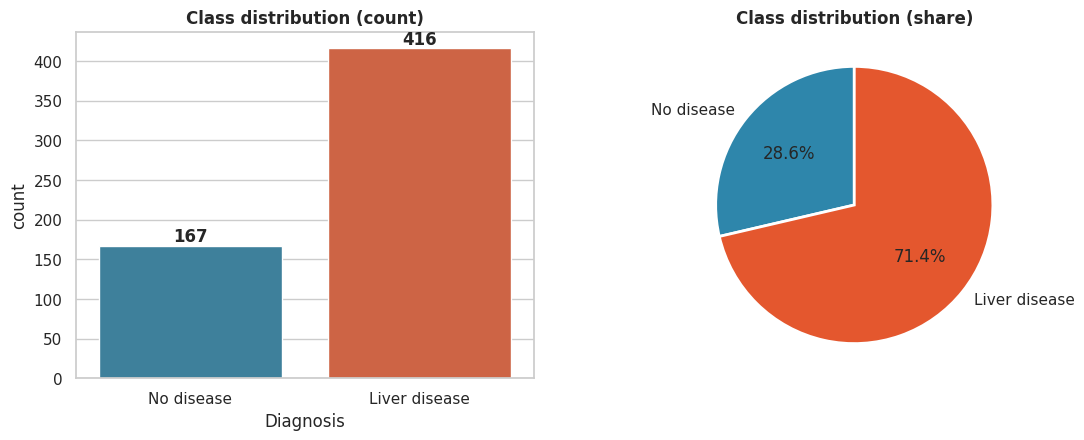

Verdict: MODERATE imbalance: accuracy alone is misleading (a trivial model reaches the majority share). Use class weights or in-fold resampling plus threshold tuning; compare them in Section 11.


In [9]:
# ============================================================
# Section 4: Target Variable Analysis
# ============================================================
counts = df[TARGET].value_counts().sort_index()
pct = 100 * counts / counts.sum()
display(pd.DataFrame({"label": [LABELS[i] for i in counts.index], "count": counts.values, "pct": pct.values},
                     index=counts.index))

IR = counts.max() / counts.min()
majority_baseline = counts.max() / counts.sum()
AUDIT["class_counts"] = {LABELS[k]: int(v) for k, v in counts.items()}
AUDIT["imbalance_ratio"] = round(float(IR), 3)
AUDIT["majority_baseline_accuracy"] = round(float(majority_baseline), 4)
print(f"Imbalance ratio (majority/minority): {IR:.2f}:1")
print(f"Majority-class baseline accuracy (predict everyone as '{LABELS[int(counts.idxmax())]}'): {majority_baseline:.2%}")

pdf = with_labels(df)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=pdf, x="Diagnosis", order=ORDER, palette=PALETTE, ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Class distribution (count)")
axes[1].pie([counts.get(0, 0), counts.get(1, 0)], labels=ORDER, colors=[PALETTE[o] for o in ORDER],
            autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class distribution (share)")
save_fig("target_distribution"); plt.show()

# Data-driven verdict
if IR < 1.5:
    verdict = "MILD imbalance: balancing is optional; monitor balanced accuracy and specificity."
elif IR < 3:
    verdict = ("MODERATE imbalance: accuracy alone is misleading (a trivial model reaches the majority share). "
               "Use class weights or in-fold resampling plus threshold tuning; compare them in Section 11.")
else:
    verdict = "SEVERE imbalance: balancing and PR-AUC-centred evaluation are mandatory."
AUDIT["imbalance_verdict"] = verdict
print("Verdict:", verdict)

### Is balancing required?
- The key number is the **majority-class baseline**: any model must clearly beat it on *balanced* metrics, otherwise high accuracy is meaningless. Here the minority class is the **healthy** group, so an unbalanced model tends to over-call disease → high sensitivity but poor specificity.
- Balancing is therefore **recommended**, but the right tool is decided empirically in Section 11. Two rules are non-negotiable: (1) resampling is applied **only on training folds** (inside the pipeline), never before splitting; (2) accuracy is always reported alongside balanced accuracy, specificity, MCC and ROC-/PR-AUC.
- Resampling changes the decision threshold much more than it changes ranking ability (ROC-AUC). Class weights + a tuned threshold often match SMOTE-type methods on small clinical datasets without creating synthetic patients.

## Section 5 — Exploratory Data Analysis
### 5.1 Univariate analysis — numerical features (histogram, KDE, boxplot, and log1p view)

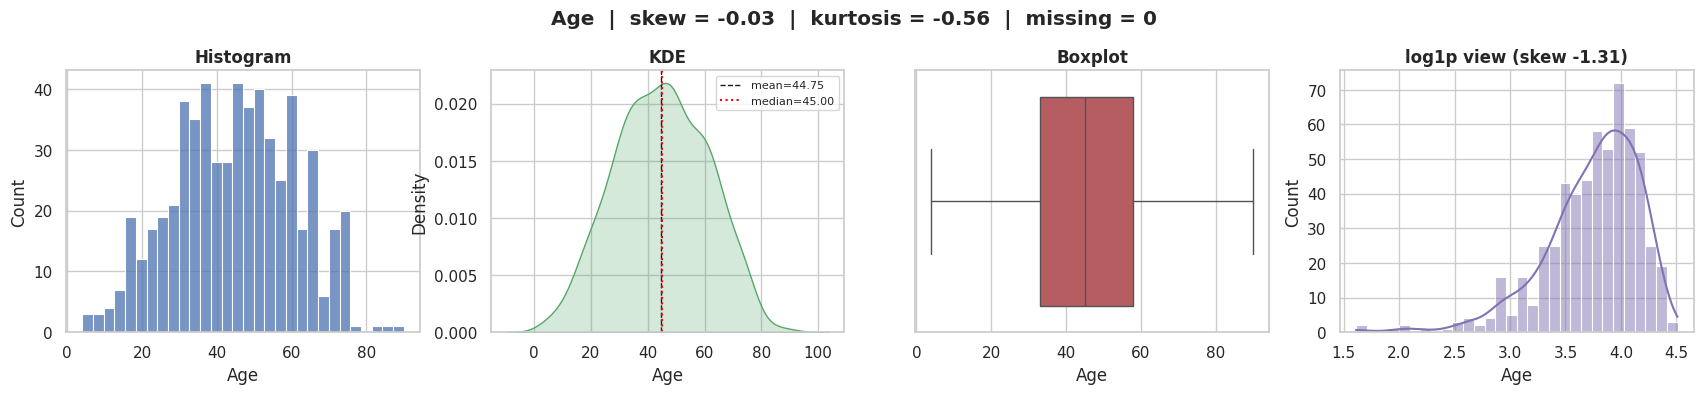

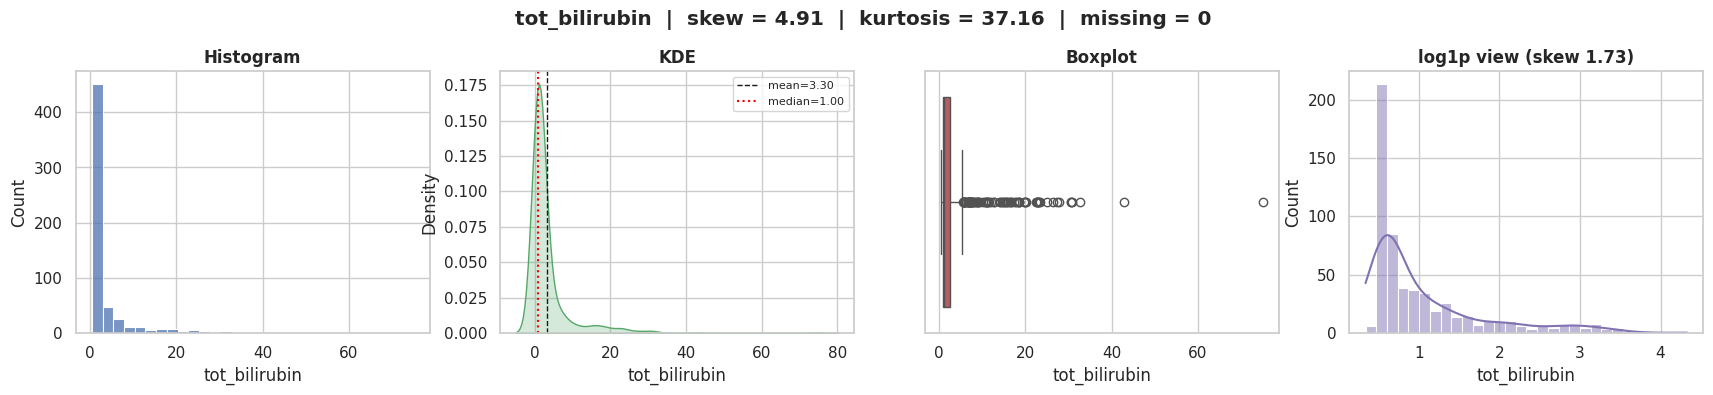

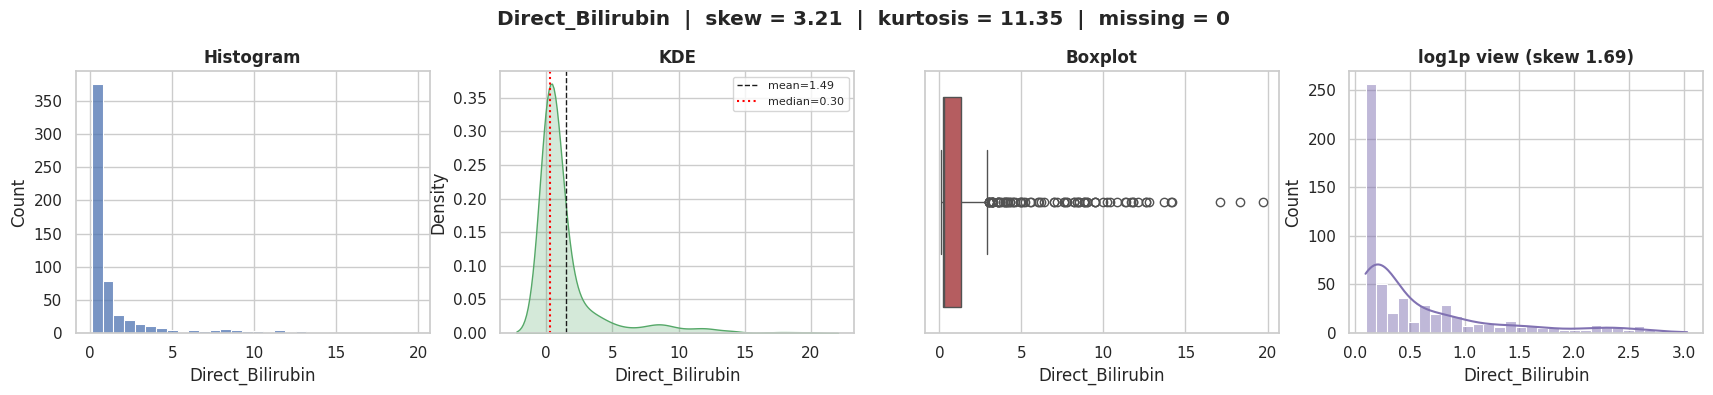

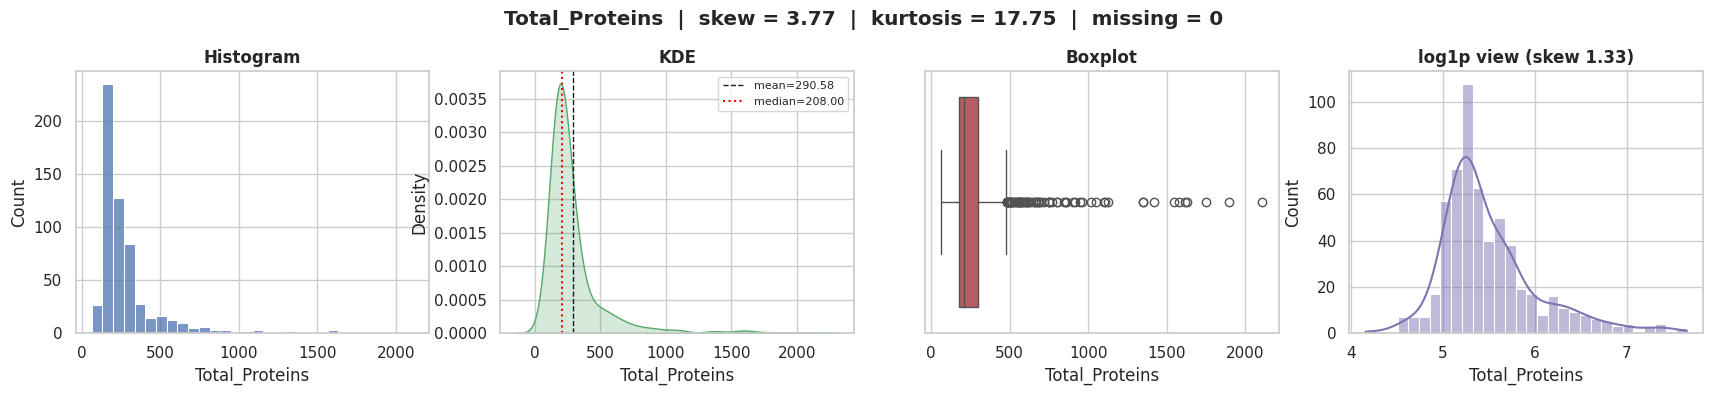

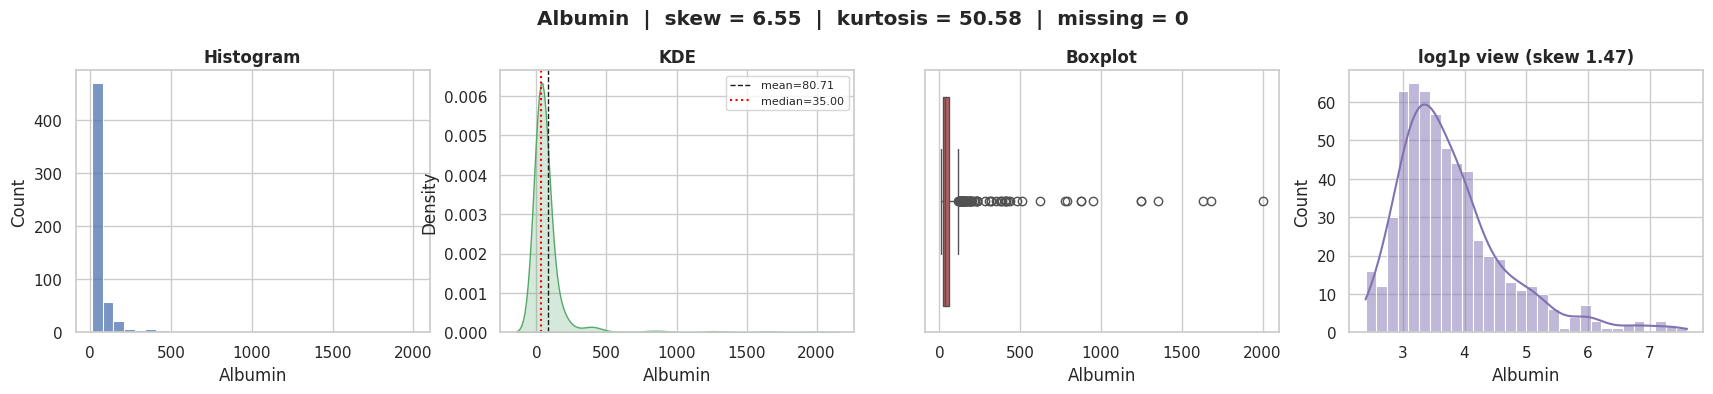

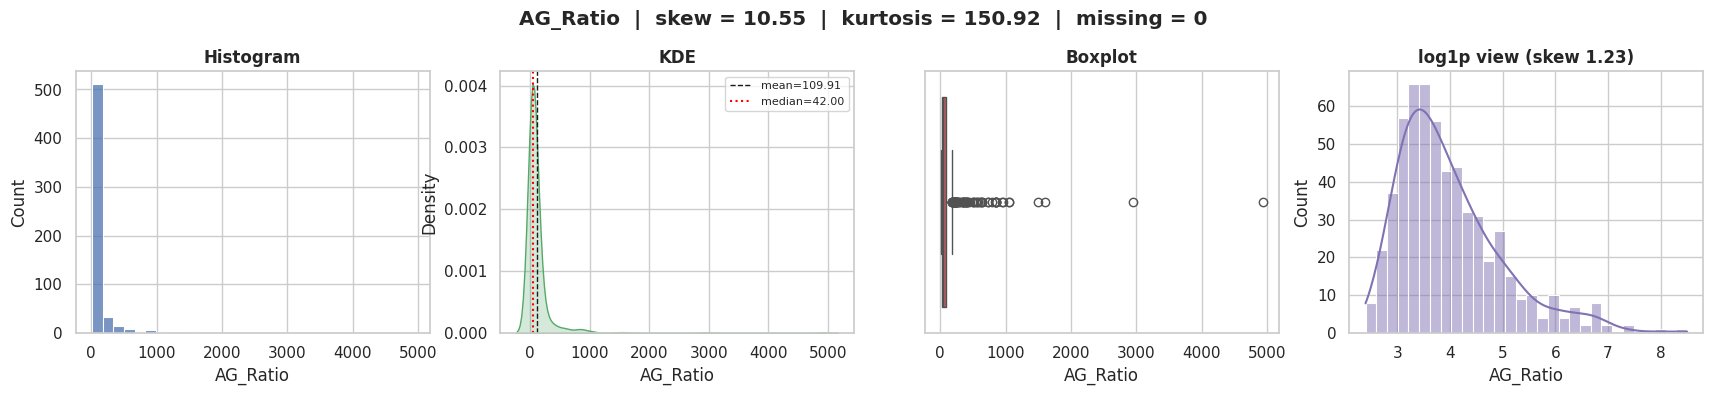

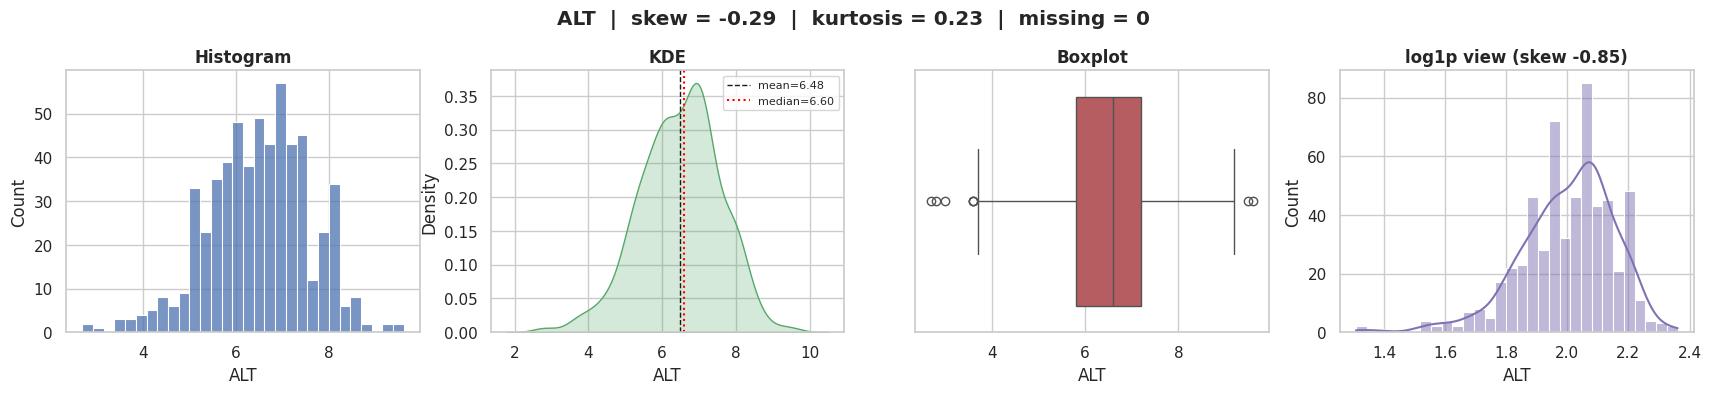

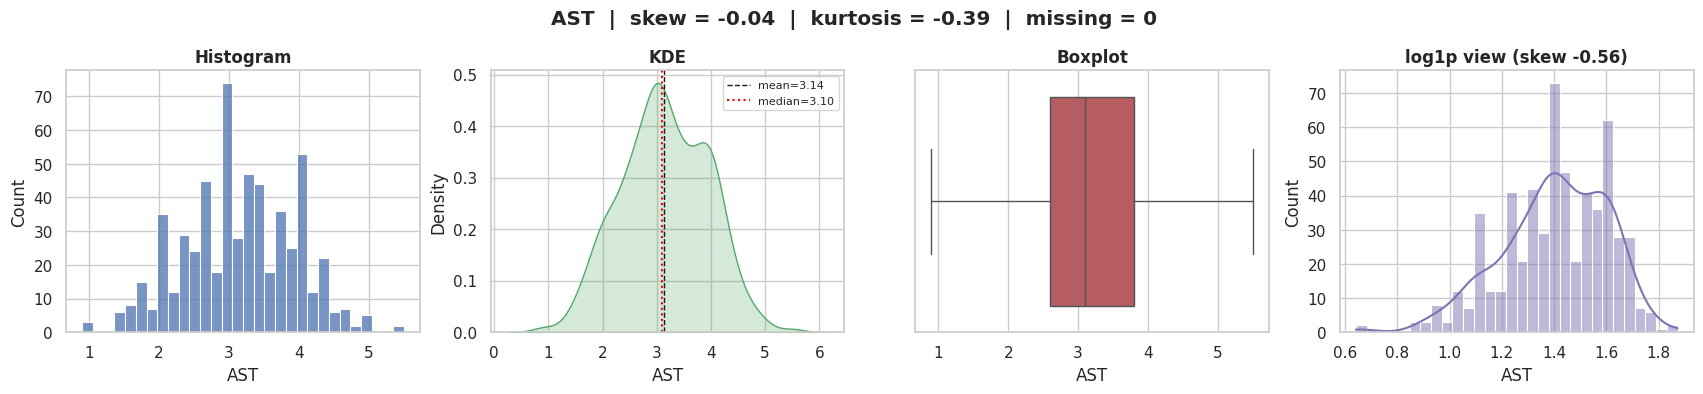

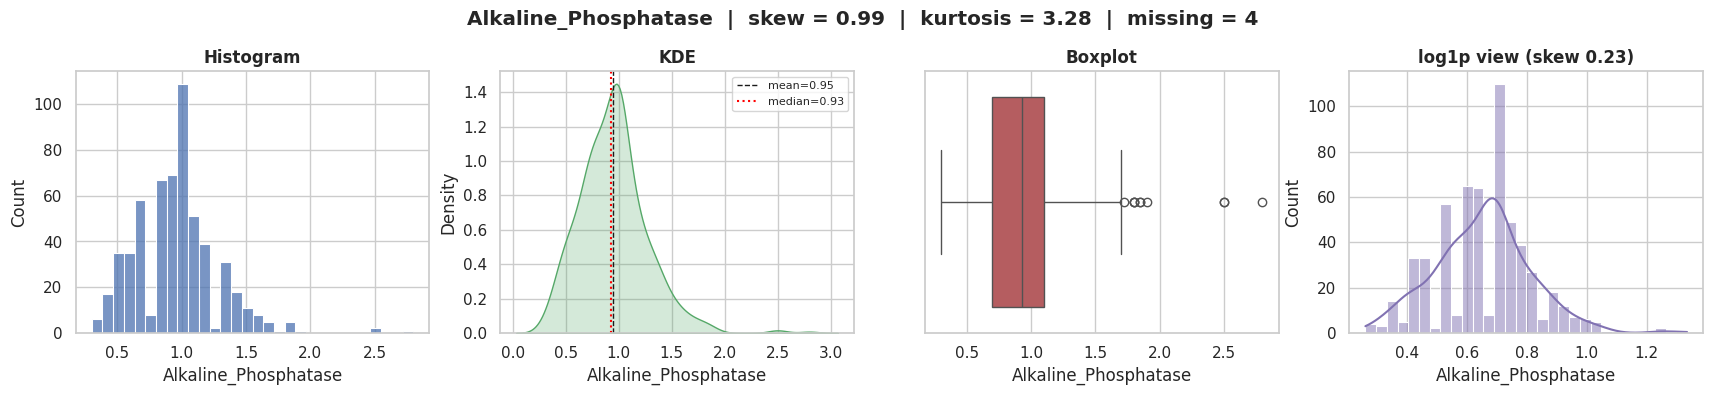

In [10]:
# ============================================================
# Section 5: Exploratory Data Analysis
# ============================================================
# 5.1 Univariate — numerical
def plot_numeric_univariate(frame, col):
    s = frame[col].dropna()
    fig, axes = plt.subplots(1, 4, figsize=(21, 3.4))
    sns.histplot(s, bins=30, ax=axes[0], color="#4C72B0")
    axes[0].set_title("Histogram")
    sns.kdeplot(s, fill=True, ax=axes[1], color="#55A868", warn_singular=False)
    axes[1].axvline(s.mean(), ls="--", c="k", lw=1, label=f"mean={s.mean():.2f}")
    axes[1].axvline(s.median(), ls=":", c="red", lw=1.5, label=f"median={s.median():.2f}")
    axes[1].legend(fontsize=8); axes[1].set_title("KDE")
    sns.boxplot(x=s, ax=axes[2], color="#C44E52")
    axes[2].set_title("Boxplot")
    if s.min() >= 0 and s.nunique() > 2:
        ls_ = np.log1p(s)
        sns.histplot(ls_, bins=30, kde=True, ax=axes[3], color="#8172B2")
        axes[3].set_title(f"log1p view (skew {ls_.skew():.2f})")
    else:
        axes[3].axis("off")
    fig.suptitle(f"{col}  |  skew = {s.skew():.2f}  |  kurtosis = {s.kurt():.2f}  |  missing = {frame[col].isna().sum()}",
                 y=1.06, fontweight="bold")
    save_fig(f"univariate_{col}"); plt.show()

for c in NUM_COLS:
    plot_numeric_univariate(df, c)

### 5.2 Univariate analysis — categorical features

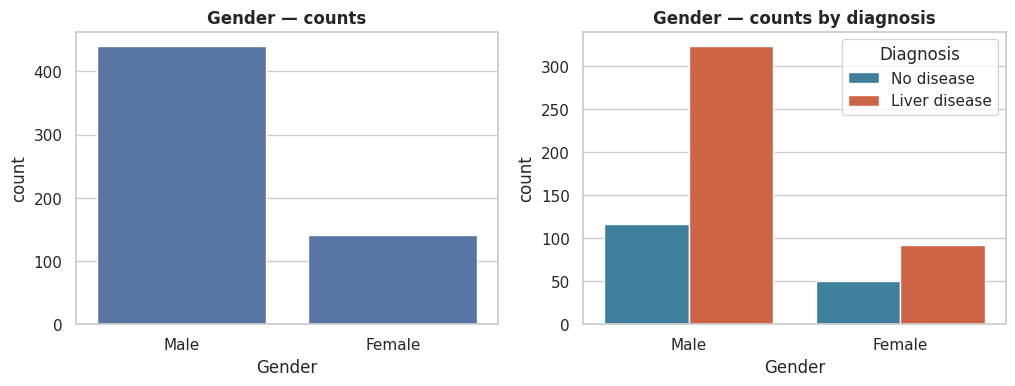

In [11]:
# 5.2 Univariate — categorical
if not CAT_COLS:
    print("No categorical features.")
for c in CAT_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    order = df[c].value_counts().index
    sns.countplot(data=df, x=c, order=order, ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"{c} — counts")
    sns.countplot(data=with_labels(df), x=c, hue="Diagnosis", hue_order=ORDER, order=order, palette=PALETTE, ax=axes[1])
    axes[1].set_title(f"{c} — counts by diagnosis")
    save_fig(f"categorical_{c}"); plt.show()

### 5.3 Bivariate analysis — features vs target (box, violin, bar of medians with 95% CI)

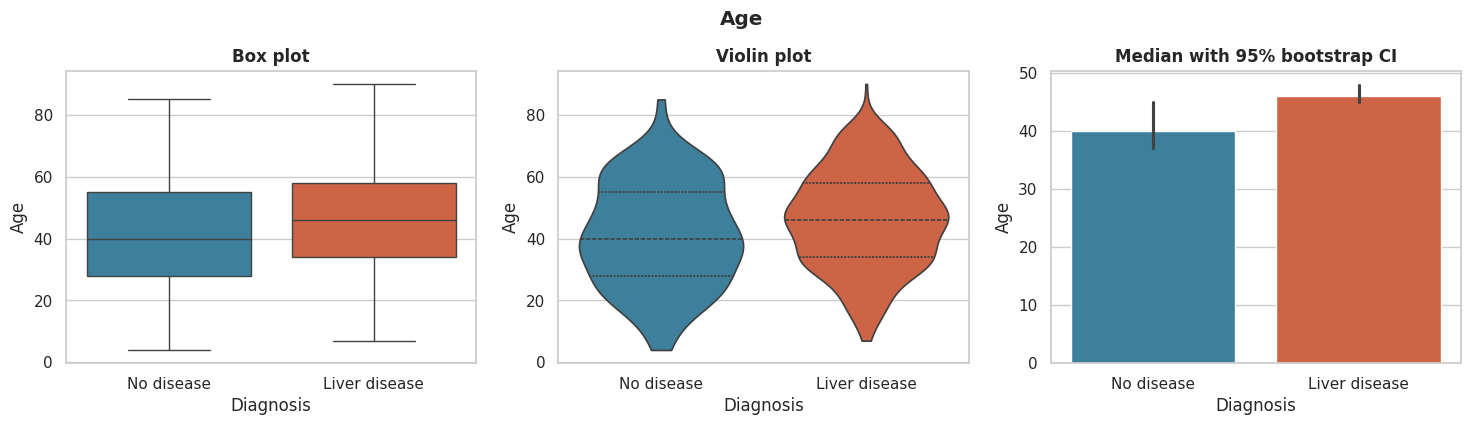

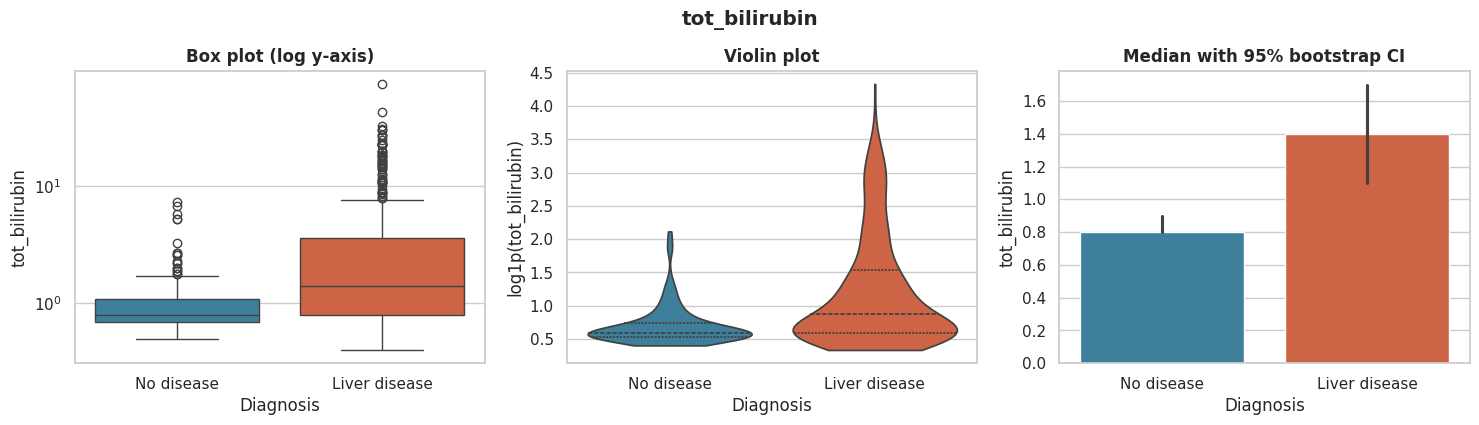

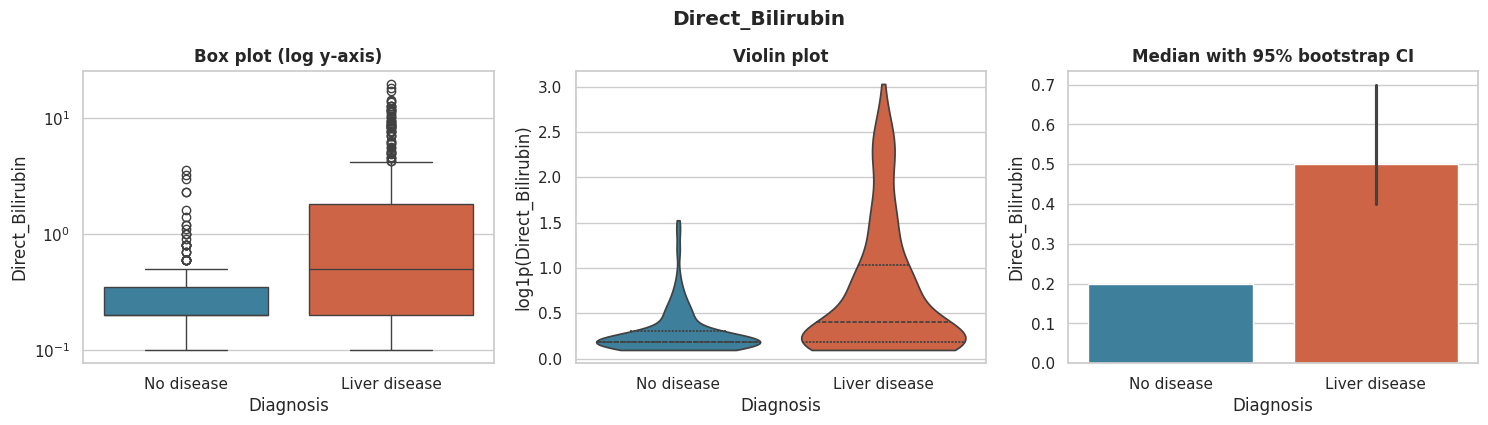

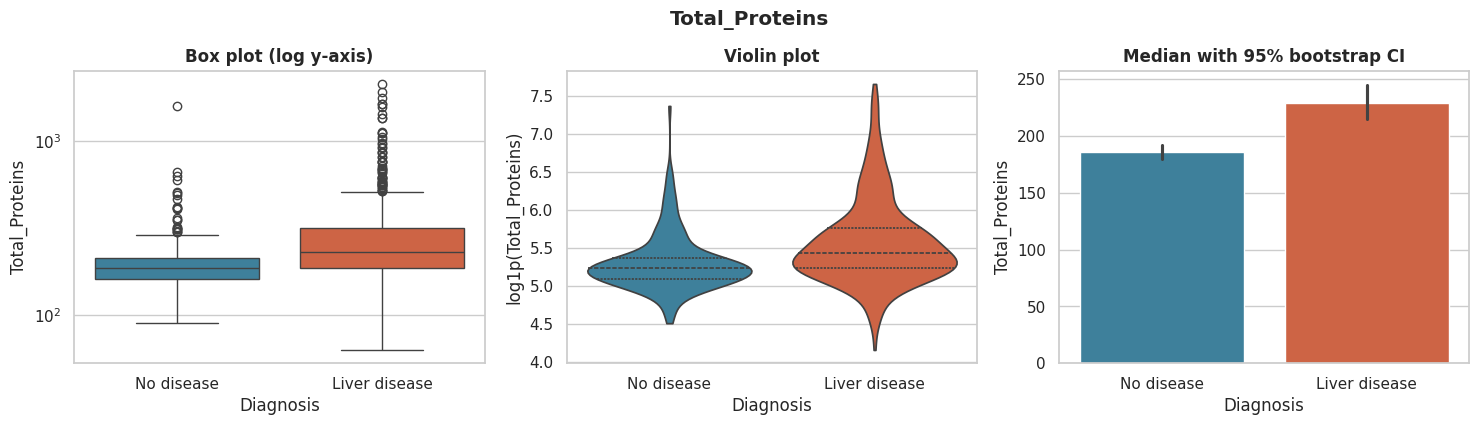

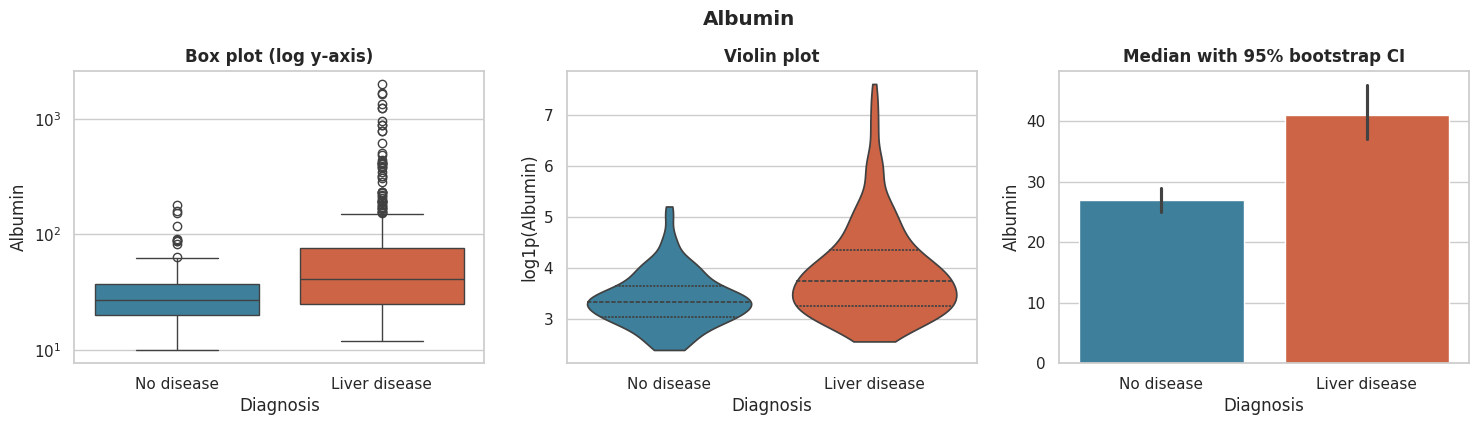

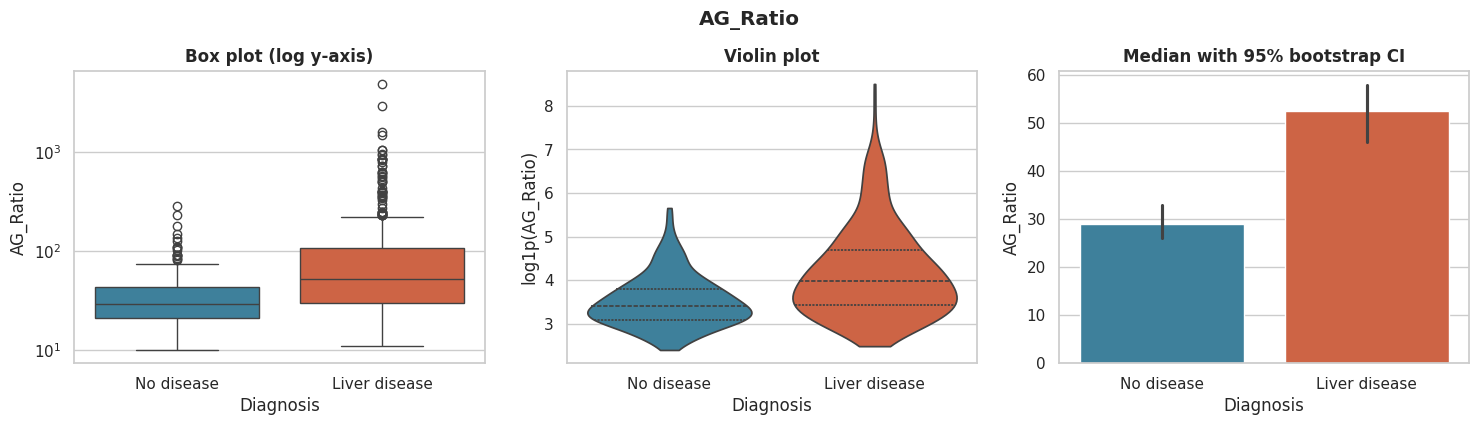

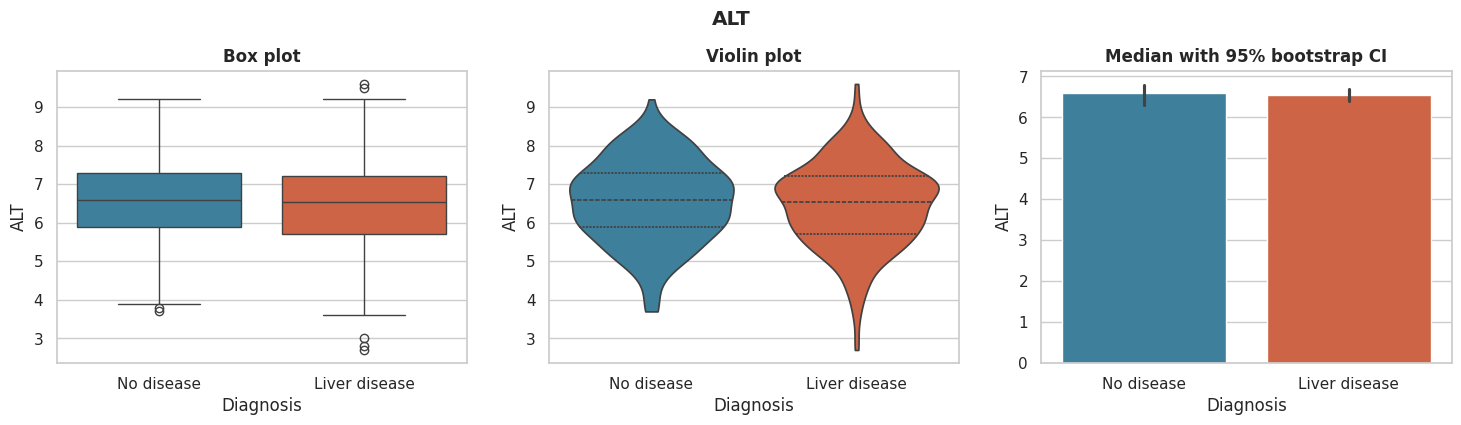

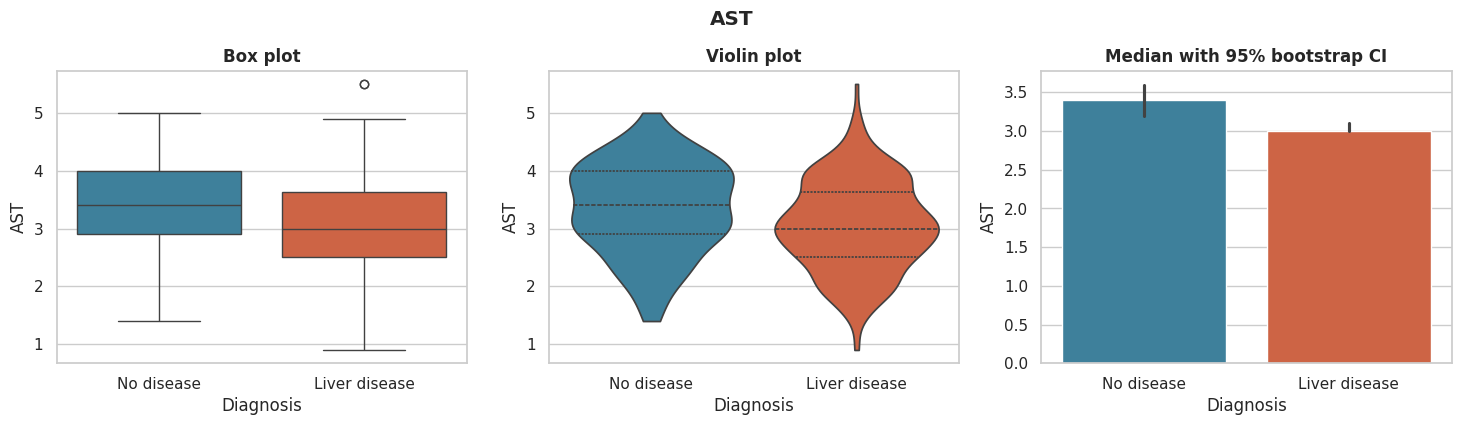

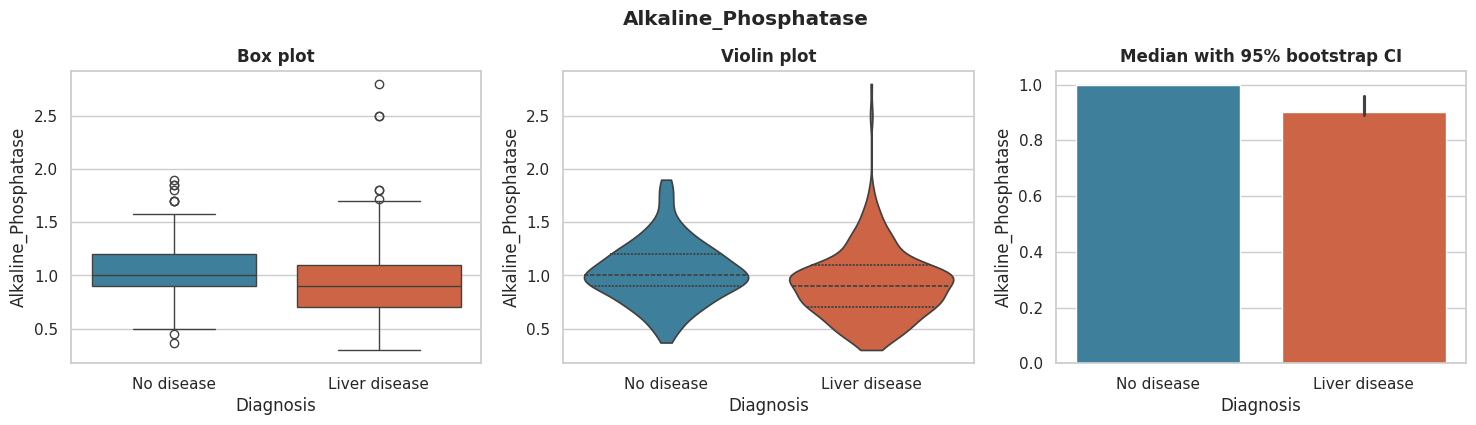

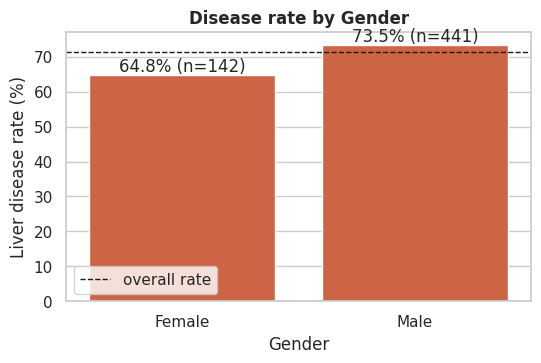

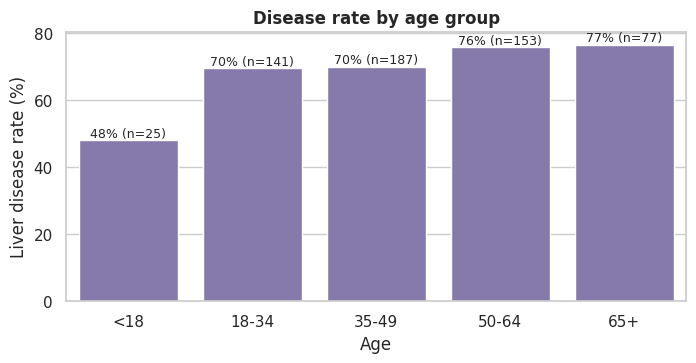

In [12]:
# 5.3 Bivariate — numerical features vs target
pdf = with_labels(df)
for c in NUM_COLS:
    use_log = c in SKEWED and df[c].min() > 0
    fig, axes = plt.subplots(1, 3, figsize=(18, 3.8))
    sns.boxplot(data=pdf, x="Diagnosis", y=c, order=ORDER, palette=PALETTE, ax=axes[0])
    if use_log:
        axes[0].set_yscale("log")
    axes[0].set_title("Box plot" + (" (log y-axis)" if use_log else ""))
    vcol = c
    if use_log:
        vcol = f"log1p({c})"
        pdf[vcol] = np.log1p(pdf[c])
    sns.violinplot(data=pdf, x="Diagnosis", y=vcol, order=ORDER, palette=PALETTE, cut=0, inner="quartile", ax=axes[1])
    axes[1].set_title("Violin plot")
    try:
        sns.barplot(data=pdf, x="Diagnosis", y=c, order=ORDER, palette=PALETTE, estimator=np.median,
                    errorbar=("ci", 95), ax=axes[2])
    except Exception:
        sns.barplot(data=pdf, x="Diagnosis", y=c, order=ORDER, palette=PALETTE, estimator=np.median, ax=axes[2])
    axes[2].set_title("Median with 95% bootstrap CI")
    fig.suptitle(c, y=1.04, fontweight="bold")
    save_fig(f"bivariate_{c}"); plt.show()

# Categorical features vs target: disease rate per category
for c in CAT_COLS:
    rate = df.groupby(c)[TARGET].agg(["mean", "count"])
    plt.figure(figsize=(6, 3.5))
    ax = sns.barplot(x=rate.index.astype(str), y=100 * rate["mean"].values, color=PALETTE[LABELS[1]])
    for i, (m, n) in enumerate(zip(rate["mean"], rate["count"])):
        ax.text(i, 100 * m + 1, f"{100 * m:.1f}% (n={n})", ha="center")
    ax.axhline(100 * df[TARGET].mean(), ls="--", c="k", lw=1, label="overall rate")
    ax.set_ylabel("Liver disease rate (%)"); ax.set_title(f"Disease rate by {c}"); ax.legend()
    save_fig(f"rate_by_{c}"); plt.show()

# Age groups vs target
if "Age" in df.columns:
    age_grp = pd.cut(df["Age"], bins=[0, 17, 34, 49, 64, 200], labels=["<18", "18-34", "35-49", "50-64", "65+"])
    rate = df.groupby(age_grp, observed=False)[TARGET].agg(["mean", "count"])
    plt.figure(figsize=(8, 3.5))
    ax = sns.barplot(x=rate.index.astype(str), y=100 * rate["mean"].values, color="#8172B2")
    for i, (m, n) in enumerate(zip(rate["mean"], rate["count"])):
        if n:
            ax.text(i, 100 * m + 1, f"{100 * m:.0f}% (n={n})", ha="center", fontsize=9)
    ax.set_ylabel("Liver disease rate (%)"); ax.set_title("Disease rate by age group")
    save_fig("rate_by_age_group"); plt.show()

### 5.4 Statistical tests and effect sizes
Non-parametric tests are used because the lab values are heavily skewed. **Univariate AUC** (how well a single feature ranks patients) is the most practical effect size: it is also an early indication of how much signal the dataset contains.

In [13]:
# 5.4 Statistical tests (Mann-Whitney U, Cliff's delta, univariate AUC, point-biserial r; BH-adjusted p)
def bh_adjust(pvals):
    p = np.asarray(pvals, float); n = len(p); order = np.argsort(p)
    ranked = p[order] * n / np.arange(1, n + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(n); out[order] = np.clip(ranked, 0, 1)
    return out

def uni_auc(y, x):
    a = roc_auc_score(y, x)
    return max(a, 1 - a), a

y_all = df[TARGET]
rows = []
for c in NUM_COLS:
    m = df[c].notna()
    a, b = df.loc[m & (y_all == 1), c], df.loc[m & (y_all == 0), c]
    if len(a) < 3 or len(b) < 3 or df.loc[m, c].nunique() < 2:
        continue
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    auc_abs, auc_raw = uni_auc(y_all[m], df.loc[m, c])
    rows.append({"feature": c, "median_disease": a.median(), "median_no_disease": b.median(),
                 "MannWhitney_p": p, "Cliffs_delta": 2 * u / (len(a) * len(b)) - 1,
                 "univariate_AUC": auc_abs, "direction": "higher in disease" if auc_raw >= 0.5 else "lower in disease",
                 "point_biserial_r": stats.pointbiserialr(y_all[m], df.loc[m, c])[0]})
tests = pd.DataFrame(rows).set_index("feature")
tests["p_BH_adjusted"] = bh_adjust(tests["MannWhitney_p"].values)
tests = tests.sort_values("univariate_AUC", ascending=False)
display(tests)
AUDIT["univariate_auc"] = tests["univariate_AUC"].round(3).to_dict()
AUDIT["max_univariate_auc"] = round(float(tests["univariate_AUC"].max()), 3)

for c in CAT_COLS:
    ct = pd.crosstab(df[c], df[TARGET])
    if ct.shape[0] > 1 and ct.shape[1] > 1:
        chi2_stat, p, dof, _ = stats.chi2_contingency(ct)
        cramers_v = np.sqrt(chi2_stat / (ct.values.sum() * (min(ct.shape) - 1)))
        print(f"{c}: chi-square = {chi2_stat:.3f}, p = {p:.4f}, Cramer's V = {cramers_v:.3f}")
        AUDIT[f"chi2_{c}"] = {"p": round(float(p), 4), "cramers_v": round(float(cramers_v), 3)}

print("\nInterpretation: |Cliff's delta| ~0.15 small, ~0.33 medium, ~0.47 large. "
      "A strongest single-feature AUC around 0.7 means moderate, overlapping class distributions.")

,median_disease,median_no_disease,MannWhitney_p,Cliffs_delta,univariate_AUC,direction,point_biserial_r,p_BH_adjusted
feature,,,,,,,,
AG_Ratio,52.5000,29.0000,0.0000,0.3944,0.6972,higher in disease,0.1519,0.0000
tot_bilirubin,1.4000,0.8000,0.0000,0.3866,0.6933,higher in disease,0.2202,0.0000
Direct_Bilirubin,0.5000,0.2000,0.0000,0.3721,0.6861,higher in disease,0.2460,0.0000
Albumin,41.0000,27.0000,0.0000,0.3712,0.6856,higher in disease,0.1634,0.0000
Total_Proteins,229.0000,186.0000,0.0000,0.3489,0.6745,higher in disease,0.1849,0.0000
Alkaline_Phosphatase,0.9000,1.0000,0.0000,-0.2399,0.6200,lower in disease,-0.1631,0.0000
AST,3.0000,3.4000,0.0001,-0.2132,0.6066,lower in disease,-0.1614,0.0001
Age,46.0000,40.0000,0.0018,0.1654,0.5827,higher in disease,0.1374,0.0020
ALT,6.5500,6.6000,0.4371,-0.0411,0.5206,lower in disease,-0.0350,0.4371


Gender: chi-square = 3.547, p = 0.0597, Cramer's V = 0.078

Interpretation: |Cliff's delta| ~0.15 small, ~0.33 medium, ~0.47 large. A strongest single-feature AUC around 0.7 means moderate, overlapping class distributions.


### 5.5 Correlation analysis (Pearson, Spearman), redundancy and multicollinearity

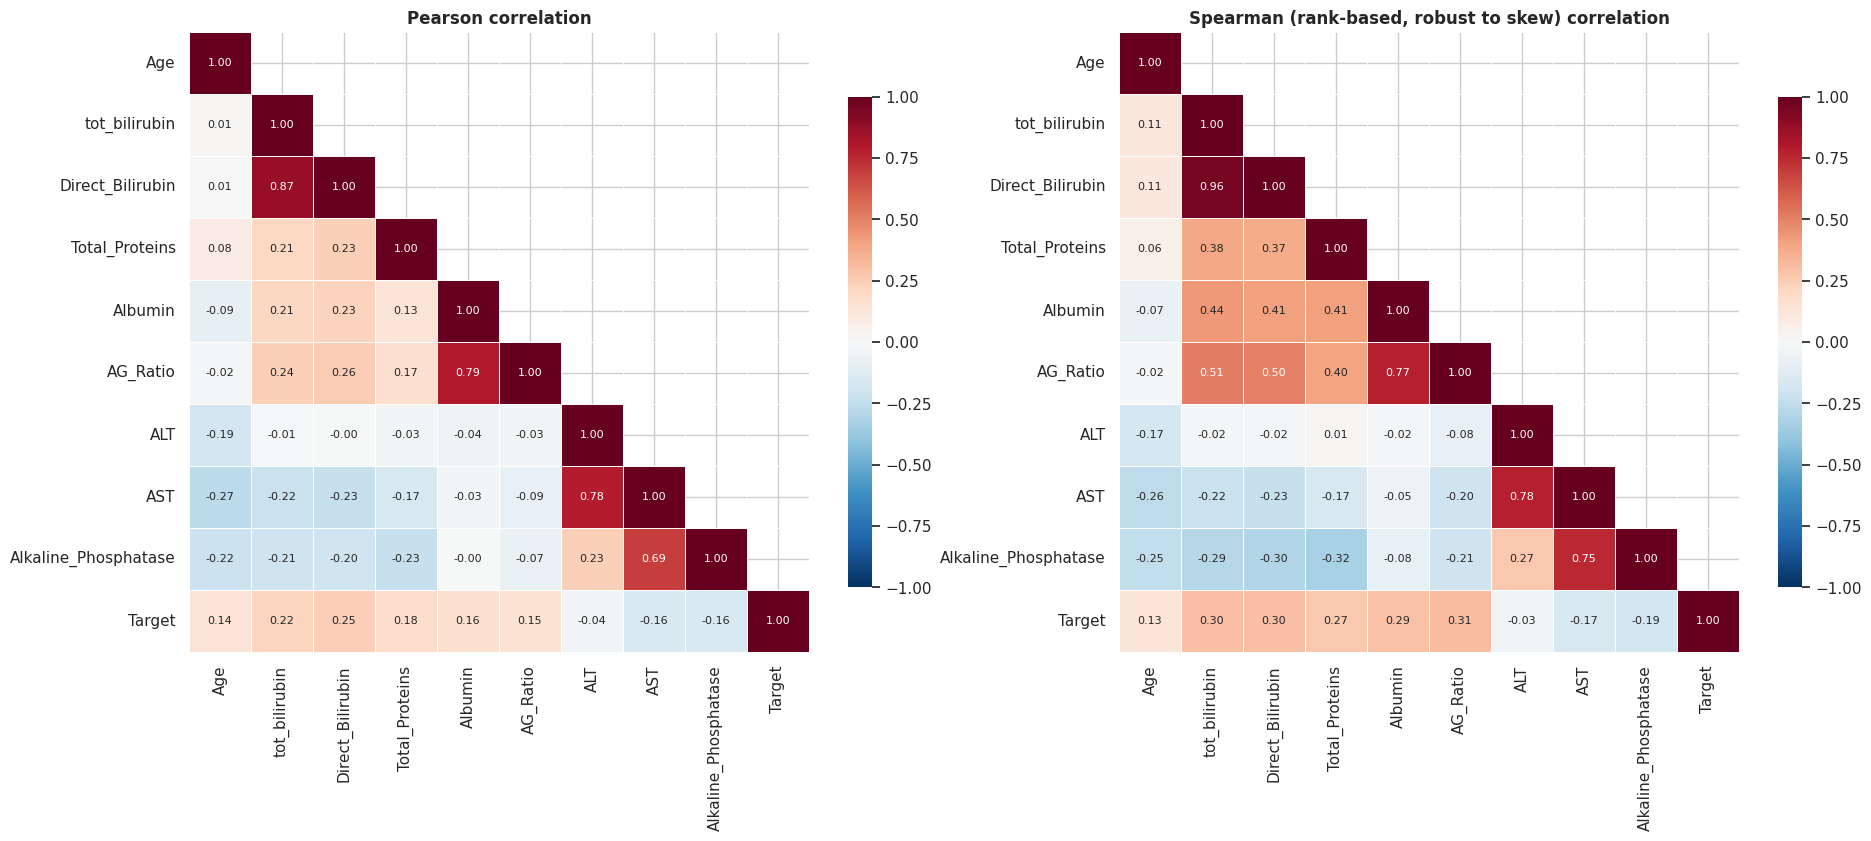

Highly correlated pairs (|r| >= 0.7):


,feature_a,feature_b,pearson,spearman
0,tot_bilirubin,Direct_Bilirubin,0.8746,0.9592
1,Albumin,AG_Ratio,0.7920,0.7736
2,ALT,AST,0.7841,0.7791
3,AST,Alkaline_Phosphatase,0.6896,0.7541


,VIF
tot_bilirubin,20.6799
Direct_Bilirubin,20.5265
AST,10.8316
ALT,5.7130
AG_Ratio,4.2010
Albumin,3.9520
Alkaline_Phosphatase,3.8421
Total_Proteins,1.2753
Age,1.0937


VIF > 5 suggests multicollinearity (matters for linear models; tree models are unaffected).


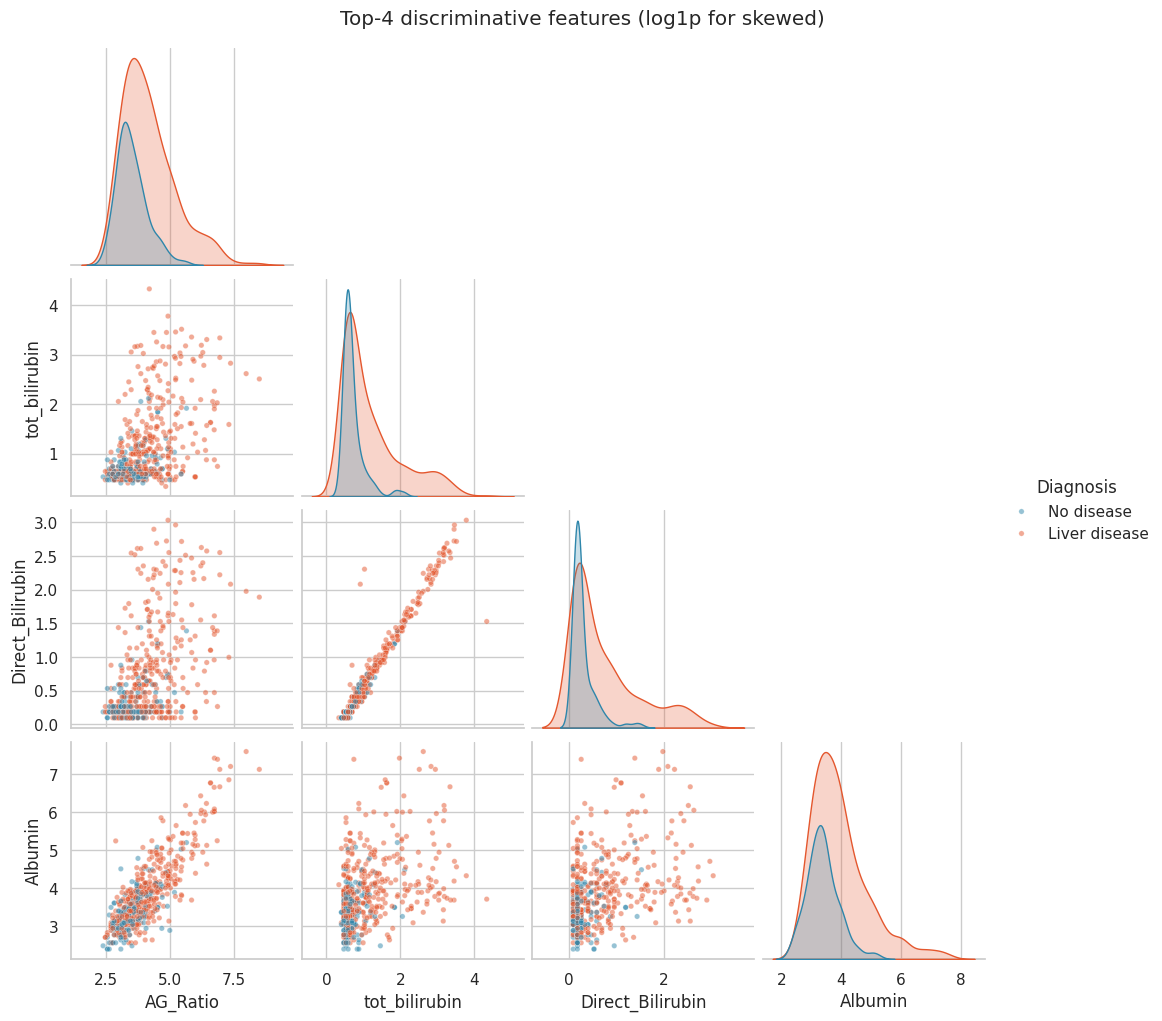

In [14]:
# 5.5 Correlation analysis
corr_cols = NUM_COLS + [TARGET]
pearson = df[corr_cols].corr(method="pearson")
spearman = df[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(22, 8.5))
for ax, (name, cm) in zip(axes, [("Pearson", pearson), ("Spearman (rank-based, robust to skew)", spearman)]):
    mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
    sns.heatmap(cm, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True,
                linewidths=.5, cbar_kws={"shrink": .75}, ax=ax, annot_kws={"size": 8})
    ax.set_title(f"{name} correlation")
save_fig("correlation_heatmaps"); plt.show()

# Highly correlated feature pairs (possible redundancy)
pairs = []
feat_only = [c for c in corr_cols if c != TARGET]
for i, a in enumerate(feat_only):
    for b in feat_only[i + 1:]:
        rp, rs = pearson.loc[a, b], spearman.loc[a, b]
        if abs(rp) >= 0.7 or abs(rs) >= 0.7:
            pairs.append({"feature_a": a, "feature_b": b, "pearson": rp, "spearman": rs})
high_corr = pd.DataFrame(pairs)
print("Highly correlated pairs (|r| >= 0.7):")
display(high_corr if len(high_corr) else "none")
AUDIT["high_corr_pairs"] = [(r["feature_a"], r["feature_b"], round(float(r["pearson"]), 2)) for _, r in high_corr.iterrows()]

# Variance Inflation Factor on log-transformed skewed features
def compute_vif(frame):
    X = frame.dropna()
    X = (X - X.mean()) / X.std(ddof=0).replace(0, 1)
    vif = {}
    for c in X.columns:
        others = X.drop(columns=c)
        r2 = LinearRegression().fit(others, X[c]).score(others, X[c])
        vif[c] = np.inf if r2 >= 0.9999 else 1 / (1 - r2)
    return pd.Series(vif, name="VIF").sort_values(ascending=False)

vif_input = df[NUM_COLS].copy()
for c in SKEWED:
    if vif_input[c].min() >= 0:
        vif_input[c] = np.log1p(vif_input[c])
if len(NUM_COLS) >= 2:
    vif = compute_vif(vif_input)
    display(vif.to_frame())
    AUDIT["high_vif"] = {k: round(float(v), 1) for k, v in vif.items() if v > 5}
    print("VIF > 5 suggests multicollinearity (matters for linear models; tree models are unaffected).")

# Pair plot of the four most discriminative features (log scale for skewed ones)
top4 = tests.index[:4].tolist()
if len(top4) >= 2:
    pp = with_labels(df)[top4 + ["Diagnosis"]].copy()
    for c in top4:
        if c in SKEWED and pp[c].min() >= 0:
            pp[c] = np.log1p(pp[c])
    g = sns.pairplot(pp.dropna(), vars=top4, hue="Diagnosis", hue_order=ORDER, palette=PALETTE,
                     corner=True, diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
    g.fig.suptitle("Top-4 discriminative features (log1p for skewed)", y=1.02)
    plt.show()

## Section 6 — Outlier Detection
Four views: classic IQR, IQR after log1p, Z-score (|z| > 3) and robust modified Z-score (MAD, > 3.5). Nothing is removed here.

,IQR_pct,IQR_after_log1p_pct,Zscore_gt3_pct,ModifiedZ_gt3.5_pct,n_IQR_outliers,disease_rate_among_IQR_outliers_pct
feature,,,,,,
Age,0.0000,2.4014,0.0000,0.0000,0,NaN
tot_bilirubin,14.4082,8.7479,2.9160,25.5575,84,96.4286
Direct_Bilirubin,13.8937,8.0617,3.2590,23.3276,81,96.2963
Total_Proteins,11.8353,6.5180,2.5729,12.1784,69,89.8551
Albumin,12.5214,4.8027,1.8868,13.0360,73,94.5205
AG_Ratio,11.3208,3.7736,1.0292,13.2075,66,96.9697
ALT,1.3722,2.5729,0.5146,0.3431,8,100.0000
AST,0.0000,0.5146,0.0000,0.0000,0,NaN
Alkaline_Phosphatase,1.7271,0.6908,0.5181,1.0363,10,60.0000


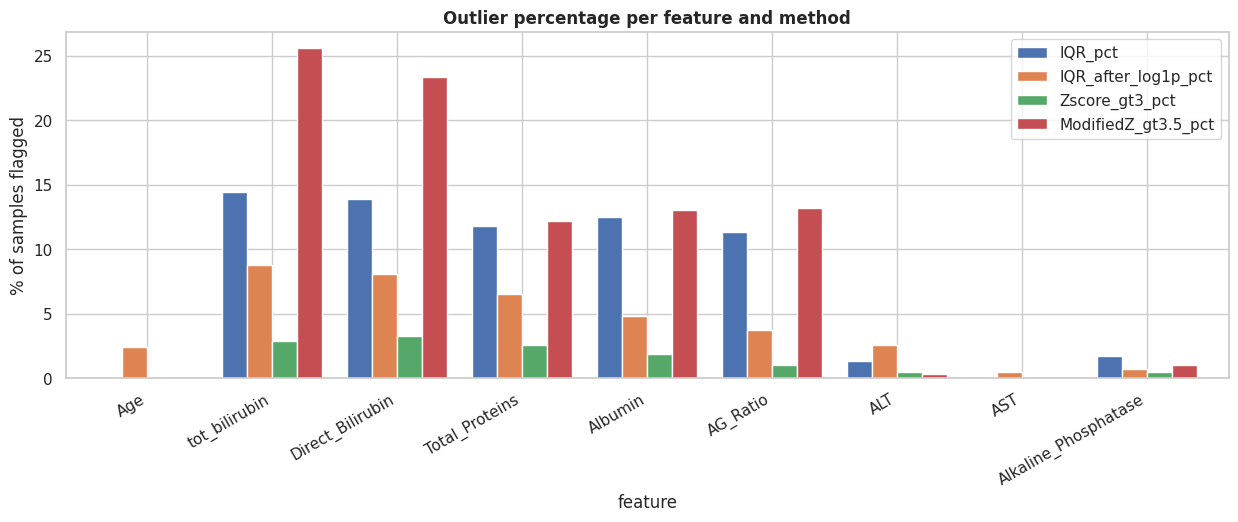

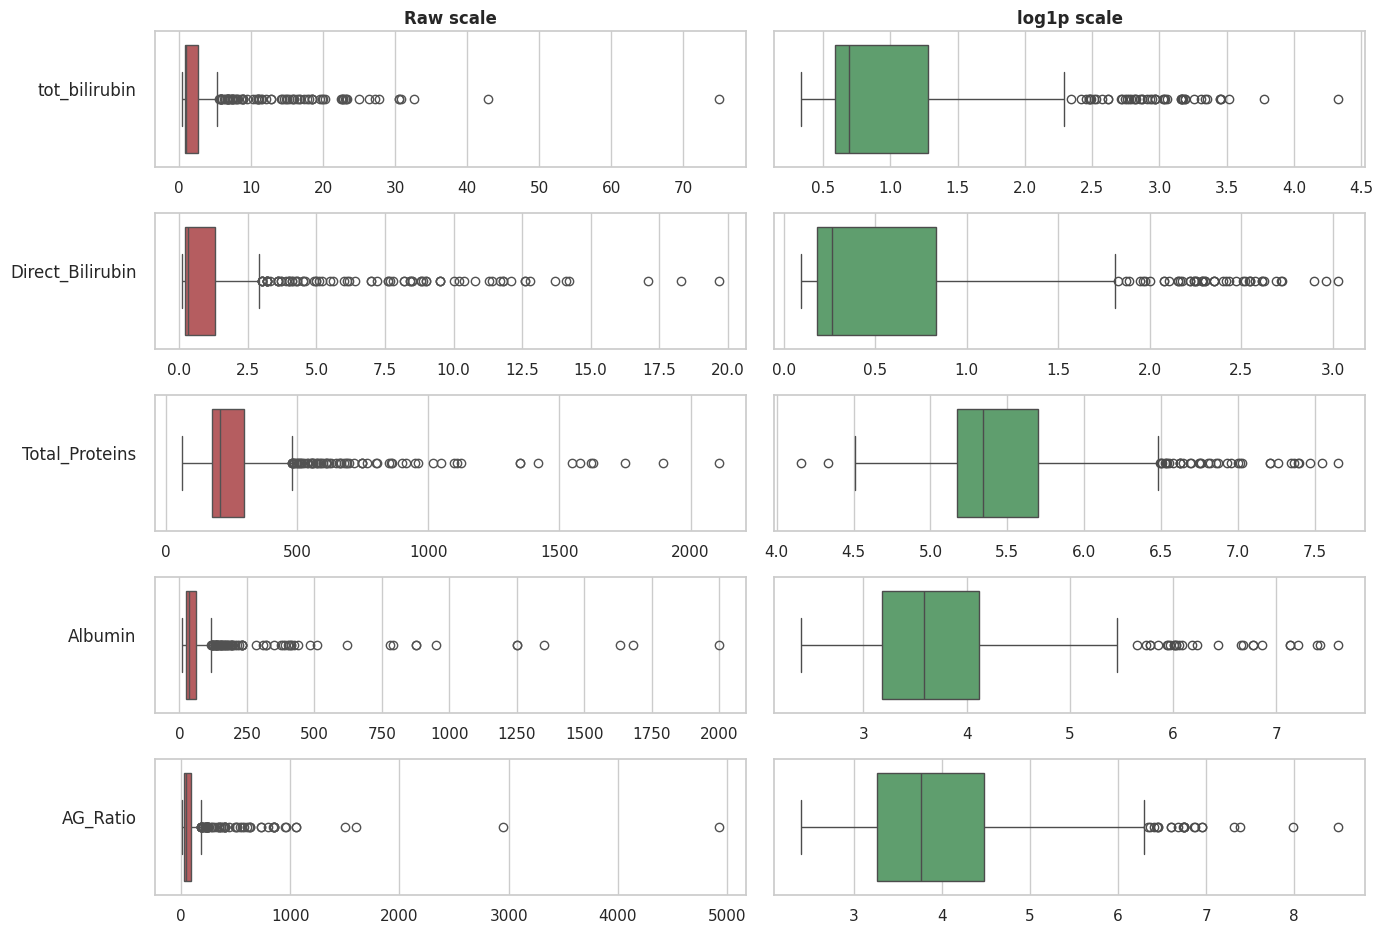

Rows with >=1 IQR outlier: 185 (31.7%) | disease rate among them: 92.4% vs overall 71.4%
Features whose 'outliers' mostly vanish after log1p (skew-driven, not errors): ['Albumin', 'AG_Ratio']


In [15]:
# ============================================================
# Section 6: Outlier Detection (analysis only — no removal)
# ============================================================
def outlier_analysis(frame, cols, target):
    rows, masks = [], {}
    for c in cols:
        s = frame[c].dropna()
        if s.nunique() <= 2:
            continue
        q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
        iqr_mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
        z_mask = pd.Series(np.abs(stats.zscore(s)) > 3, index=s.index)
        med = s.median(); mad = np.median(np.abs(s - med))
        mz_mask = (0.6745 * (s - med).abs() / mad > 3.5) if mad > 0 else pd.Series(False, index=s.index)
        if s.min() >= 0:
            ls_ = np.log1p(s); lq1, lq3 = ls_.quantile([.25, .75]); liqr = lq3 - lq1
            log_pct = 100 * ((ls_ < lq1 - 1.5 * liqr) | (ls_ > lq3 + 1.5 * liqr)).mean()
        else:
            log_pct = np.nan
        rows.append({"feature": c,
                     "IQR_pct": 100 * iqr_mask.mean(), "IQR_after_log1p_pct": log_pct,
                     "Zscore_gt3_pct": 100 * z_mask.mean(), "ModifiedZ_gt3.5_pct": 100 * mz_mask.mean(),
                     "n_IQR_outliers": int(iqr_mask.sum()),
                     "disease_rate_among_IQR_outliers_pct": 100 * target.loc[iqr_mask[iqr_mask].index].mean()
                                                            if iqr_mask.any() else np.nan})
        masks[c] = iqr_mask
    return pd.DataFrame(rows).set_index("feature"), masks

out_df, out_masks = outlier_analysis(df, NUM_COLS, df[TARGET])
display(out_df)

out_df[["IQR_pct", "IQR_after_log1p_pct", "Zscore_gt3_pct", "ModifiedZ_gt3.5_pct"]].plot.bar(figsize=(15, 4.5), width=0.8)
plt.ylabel("% of samples flagged"); plt.title("Outlier percentage per feature and method"); plt.xticks(rotation=30, ha="right")
save_fig("outlier_percentages"); plt.show()

# Raw vs log1p boxplots for skewed features
skew_plot = [c for c in SKEWED if df[c].min() >= 0]
if skew_plot:
    fig, axes = plt.subplots(len(skew_plot), 2, figsize=(14, 1.9 * len(skew_plot)), squeeze=False)
    for i, c in enumerate(skew_plot):
        sns.boxplot(x=df[c], ax=axes[i, 0], color="#C44E52"); axes[i, 0].set_xlabel(""); axes[i, 0].set_ylabel(c, rotation=0, ha="right")
        sns.boxplot(x=np.log1p(df[c]), ax=axes[i, 1], color="#55A868"); axes[i, 1].set_xlabel("")
    axes[0, 0].set_title("Raw scale"); axes[0, 1].set_title("log1p scale")
    plt.tight_layout(); save_fig("outliers_raw_vs_log"); plt.show()

# Are outliers informative?
any_out = pd.concat(out_masks.values(), axis=1).reindex(df.index).fillna(False).any(axis=1) if out_masks else pd.Series(False, index=df.index)
rate_out = df.loc[any_out, TARGET].mean() if any_out.any() else np.nan
print(f"Rows with >=1 IQR outlier: {int(any_out.sum())} ({100 * any_out.mean():.1f}%) | "
      f"disease rate among them: {100 * rate_out:.1f}% vs overall {100 * df[TARGET].mean():.1f}%")
skew_driven = out_df.index[(out_df["IQR_pct"] > 5) & (out_df["IQR_after_log1p_pct"] < 0.5 * out_df["IQR_pct"])].tolist()
AUDIT["outliers"] = {"rows_with_iqr_outlier_pct": round(float(100 * any_out.mean()), 1),
                     "disease_rate_among_outlier_rows_pct": round(float(100 * rate_out), 1) if pd.notna(rate_out) else None,
                     "skew_driven_features": skew_driven}
print(f"Features whose 'outliers' mostly vanish after log1p (skew-driven, not errors): {skew_driven}")

### Should outliers be removed? — No (for this dataset)
- Extreme bilirubin and aminotransferase (ALT/AST) and ALP values are **clinically real**: very high enzyme levels are exactly what liver injury looks like. Removing them deletes the most informative patients, often disproportionately from the disease class (check the disease rate among outlier rows above).
- Most IQR "outliers" are an artifact of right skew: after `log1p` their share drops sharply. The correct treatment is a **transformation** (log1p / Yeo-Johnson) plus a **robust scaler**, not deletion.
- Tree ensembles are invariant to monotone transformations and insensitive to extreme values; linear/SVM/KNN models benefit from the log transform.
- Only values that fail the consistency checks of Section 3.5 (impossible values) would justify correction or exclusion, and those should be documented individually.

## Section 7 — Missing Value Analysis

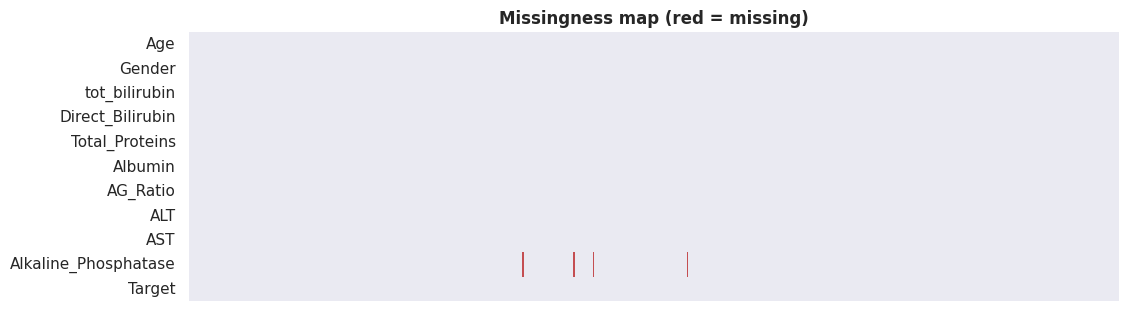

Incomplete rows: 4


,Age,Gender,tot_bilirubin,Direct_Bilirubin,Total_Proteins,Albumin,AG_Ratio,ALT,AST,Alkaline_Phosphatase,Target
209,45,Female,0.9000,0.3000,189,23,33,6.6000,3.9000,NaN,1
241,51,Male,0.8000,0.2000,230,24,46,6.5000,3.1000,NaN,1
253,35,Female,0.6000,0.2000,180,12,15,5.2000,2.7000,NaN,0
312,27,Male,1.3000,0.6000,106,25,54,8.5000,4.8000,NaN,0


Target distribution among incomplete rows: {'Liver disease': 2, 'No disease': 2}

A/G recomputation check on complete rows: median |error| = 39.780, within 0.1 = 0.0%, Spearman rho = 0.476
Missing A/G values recoverable exactly from Albumin and Total_Proteins: 0
=> Formula does not match well; use statistical imputation.


In [16]:
# ============================================================
# Section 7: Missing Value Analysis
# ============================================================
miss_cols = [c for c in df.columns if df[c].isna().any()]
if miss_cols:
    fig, ax = plt.subplots(figsize=(12, 3.5))
    sns.heatmap(df.isna().T, cbar=False, cmap=["#EAEAF2", "#C44E52"], ax=ax, xticklabels=False)
    ax.set_title("Missingness map (red = missing)"); save_fig("missing_map"); plt.show()
    incomplete = df[df.isna().any(axis=1)]
    print(f"Incomplete rows: {len(incomplete)}")
    display(incomplete)
    print("Target distribution among incomplete rows:", incomplete[TARGET].map(LABELS).value_counts().to_dict())
else:
    print("No missing values in the features.")

# 7.1 Domain-based deterministic repair: A/G ratio = Albumin / (Total_Proteins - Albumin)
AG_DETERMINISTIC = False
if has("AG_Ratio", "Albumin", "Total_Proteins"):
    glob = df["Total_Proteins"] - df["Albumin"]
    ag_calc = df["Albumin"] / glob.where(glob > 0)
    ok = df["AG_Ratio"].notna() & ag_calc.notna()
    abs_err = (df.loc[ok, "AG_Ratio"] - ag_calc[ok]).abs()
    rho = stats.spearmanr(df.loc[ok, "AG_Ratio"], ag_calc[ok])[0]
    fillable = int((df["AG_Ratio"].isna() & ag_calc.notna()).sum())
    AG_DETERMINISTIC = bool(abs_err.median() < 0.1 and rho > 0.9)
    print(f"\nA/G recomputation check on complete rows: median |error| = {abs_err.median():.3f}, "
          f"within 0.1 = {100 * (abs_err <= 0.1).mean():.1f}%, Spearman rho = {rho:.3f}")
    print(f"Missing A/G values recoverable exactly from Albumin and Total_Proteins: {fillable}")
    print("=> Deterministic recomputation is valid." if AG_DETERMINISTIC else "=> Formula does not match well; use statistical imputation.")
AUDIT["ag_ratio_deterministic_repair"] = AG_DETERMINISTIC

In [17]:
# 7.2 Imputation benchmark: mask known values, impute, measure normalized RMSE (lower = better)
def imputation_benchmark(frame, cols, frac=0.10, repeats=3):
    base = frame[cols].dropna().copy()
    skewed = [c for c in cols if base[c].min() >= 0 and base[c].skew() > 1]
    base[skewed] = np.log1p(base[skewed])                 # evaluate on the scale models will use
    Z = ((base - base.mean()) / base.std(ddof=0).replace(0, 1)).values
    imputers = OrderedDict([
        ("Median", SimpleImputer(strategy="median")),
        ("KNN (k=5)", KNNImputer(n_neighbors=5, weights="distance")),
        ("Iterative (BayesianRidge)", IterativeImputer(estimator=BayesianRidge(), max_iter=25, random_state=SEED)),
        ("MissForest-style (ExtraTrees)", IterativeImputer(
            estimator=ExtraTreesRegressor(n_estimators=50, min_samples_leaf=2, n_jobs=N_JOBS, random_state=SEED),
            max_iter=5, random_state=SEED)),
    ])
    rng = np.random.default_rng(SEED)
    scores = {k: [] for k in imputers}
    for _ in range(repeats):
        mask = rng.random(Z.shape) < frac
        mask[mask.all(axis=1)] = False                    # never mask an entire row
        Zm = Z.copy(); Zm[mask] = np.nan
        for name, imp in imputers.items():
            Zi = clone(imp).fit_transform(Zm)
            scores[name].append(np.sqrt(np.mean((Zi[mask] - Z[mask]) ** 2)))
    return pd.DataFrame({"NRMSE_mean": {k: np.mean(v) for k, v in scores.items()},
                         "NRMSE_sd": {k: np.std(v) for k, v in scores.items()}}).sort_values("NRMSE_mean")

imp_bench = imputation_benchmark(df, NUM_COLS)
display(imp_bench)
BEST_IMPUTER_MASKING = imp_bench.index[0]
total_missing_pct = 100 * df[FEATURES_RAW].isna().sum().sum() / df[FEATURES_RAW].size
AUDIT["imputation_benchmark_best"] = BEST_IMPUTER_MASKING
AUDIT["total_missing_cell_pct"] = round(float(total_missing_pct), 3)

print(f"Overall missing cells: {total_missing_pct:.3f}% | best reconstruction: {BEST_IMPUTER_MASKING}")
if total_missing_pct < 1:
    print("=> Missingness is tiny: the imputer choice has negligible effect on model performance. "
          "Use the deterministic A/G repair where possible, then a simple, fold-safe imputer; "
          "the downstream comparison in Section 10 makes the final call.")
else:
    print(f"=> Missingness is non-trivial: prefer {BEST_IMPUTER_MASKING}, fitted inside CV folds.")

def get_imputer(name):
    if name.startswith("KNN"):
        return KNNImputer(n_neighbors=5, weights="distance")
    if name.startswith("Iterative"):
        return IterativeImputer(estimator=BayesianRidge(), max_iter=25, random_state=SEED)
    if name.startswith("MissForest"):
        return IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=50, min_samples_leaf=2, n_jobs=1,
                                                              random_state=SEED), max_iter=5, random_state=SEED)
    return SimpleImputer(strategy="median")

,NRMSE_mean,NRMSE_sd
Iterative (BayesianRidge),0.6336,0.0118
MissForest-style (ExtraTrees),0.6455,0.0211
KNN (k=5),0.7852,0.0010
Median,1.0601,0.0263


Overall missing cells: 0.069% | best reconstruction: Iterative (BayesianRidge)
=> Missingness is tiny: the imputer choice has negligible effect on model performance. Use the deterministic A/G repair where possible, then a simple, fold-safe imputer; the downstream comparison in Section 10 makes the final call.


**How to read this:** missingness in ILPD is confined to very few cells (typically only the A/G ratio). Because the A/G ratio is *defined* as Albumin / (Total protein − Albumin), it can be recomputed exactly instead of estimated — the most defensible "imputation" possible. Any remaining gaps are filled by an imputer fitted **inside** each training fold (never on the full dataset).

## Section 8 — Feature Engineering
Clinically motivated features (all **stateless**, i.e. computed row by row, so they cannot leak information across folds):

| Feature | Definition | Clinical rationale |
|---|---|---|
| `Indirect_Bilirubin` | Total − Direct bilirubin | unconjugated fraction (hemolysis / conjugation defects) |
| `DB_TB_Ratio` | Direct / Total bilirubin | high share suggests cholestatic / hepatocellular pattern |
| `AST_ALT_Ratio` | AST / ALT (De Ritis ratio) | > 1 associated with advanced fibrosis / alcoholic injury |
| `ALP_ALT_Ratio` | ALP / ALT | cholestatic vs hepatocellular injury pattern (related to the R-ratio) |
| `Globulin` | Total protein − Albumin | chronic inflammation / immune activity |
| `Enzyme_Load` | log ALT + log AST + log ALP | overall enzyme elevation |
| `Flag_*` | TB > 1.2, DB > 0.3 mg/dL; ALT, AST > 40 U/L; Albumin < 3.5 g/dL; A/G < 1.0 | common reference limits (lab-dependent) |
| `Abnormal_Test_Count` | number of abnormal flags | simple clinical burden score |
| `Age_Group` | ordinal age band | captures non-linear age effects for linear models |

No ALP flag is created: ILPD's ALP values are high relative to typical adult reference ranges, which suggests a different assay/unit convention, so a fixed cut-off would be unreliable.

In [18]:
# ============================================================
# Section 8: Feature Engineering
# ============================================================
EPS = 1e-6

def basic_encode(frame):
    """Minimal encoding: Gender -> Gender_Male (0/1); coerce anything else to numeric."""
    X = frame.copy()
    if "Gender" in X.columns and not pd.api.types.is_numeric_dtype(X["Gender"]):
        X["Gender_Male"] = X["Gender"].map({"Male": 1.0, "Female": 0.0})
        X = X.drop(columns="Gender")
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]):
            X[c] = pd.to_numeric(X[c], errors="coerce")
    return X

def engineer_features(frame):
    """Stateless clinical feature engineering (safe to use inside CV pipelines)."""
    X = basic_encode(frame)
    has_ = lambda *cols: all(c in X.columns for c in cols)
    if has_("AG_Ratio", "Albumin", "Total_Proteins"):          # deterministic A/G repair
        glob = X["Total_Proteins"] - X["Albumin"]
        X["AG_Ratio"] = X["AG_Ratio"].fillna(X["Albumin"] / glob.where(glob > 0))
    if has_("Total_Proteins", "Albumin"):
        X["Globulin"] = (X["Total_Proteins"] - X["Albumin"]).clip(lower=0)
    if has_("Total_Bilirubin", "Direct_Bilirubin"):
        X["Indirect_Bilirubin"] = (X["Total_Bilirubin"] - X["Direct_Bilirubin"]).clip(lower=0)
        X["DB_TB_Ratio"] = (X["Direct_Bilirubin"] / (X["Total_Bilirubin"] + EPS)).clip(0, 1)
    if has_("AST", "ALT"):
        X["AST_ALT_Ratio"] = X["AST"] / (X["ALT"] + EPS)
    if has_("Alkaline_Phosphatase", "ALT"):
        X["ALP_ALT_Ratio"] = X["Alkaline_Phosphatase"] / (X["ALT"] + EPS)
    if has_("ALT", "AST", "Alkaline_Phosphatase"):
        X["Enzyme_Load"] = np.log1p(X["ALT"]) + np.log1p(X["AST"]) + np.log1p(X["Alkaline_Phosphatase"])
    flag_rules = [("Flag_High_TB", "Total_Bilirubin", ">", 1.2), ("Flag_High_DB", "Direct_Bilirubin", ">", 0.3),
                  ("Flag_High_ALT", "ALT", ">", 40), ("Flag_High_AST", "AST", ">", 40),
                  ("Flag_Low_Albumin", "Albumin", "<", 3.5), ("Flag_Low_AG", "AG_Ratio", "<", 1.0)]
    for name, col, op, thr in flag_rules:
        if col in X.columns:
            cond = X[col] > thr if op == ">" else X[col] < thr
            X[name] = cond.astype(float).where(X[col].notna())
    flag_cols = [c for c in X.columns if c.startswith("Flag_")]
    if flag_cols:
        X["Abnormal_Test_Count"] = X[flag_cols].sum(axis=1, min_count=1)
    if "Age" in X.columns:
        X["Age_Group"] = pd.cut(X["Age"], bins=[0, 17, 34, 49, 64, 200], labels=False).astype(float)
    return X

# 8.1 Transformation analysis: raw vs log1p vs Yeo-Johnson skewness
rows = []
for c in NUM_COLS:
    s = df[c].dropna()
    rows.append({"feature": c, "skew_raw": s.skew(),
                 "skew_log1p": np.log1p(s).skew() if s.min() >= 0 else np.nan,
                 "skew_yeo_johnson": pd.Series(PowerTransformer(method="yeo-johnson").fit_transform(s.to_frame()).ravel()).skew()})
display(pd.DataFrame(rows).set_index("feature"))
print("log1p is interpretable and removes most skew; Yeo-Johnson is a data-fitted alternative (must be fitted in-fold).")

,skew_raw,skew_log1p,skew_yeo_johnson
feature,,,
Age,-0.0294,-1.3102,-0.0796
tot_bilirubin,4.9075,1.7281,0.5400
Direct_Bilirubin,3.2124,1.6887,0.5701
Total_Proteins,3.7651,1.3311,-0.0473
Albumin,6.5492,1.4738,0.0884
AG_Ratio,10.5462,1.2327,0.1156
ALT,-0.2857,-0.8487,-0.0016
AST,-0.0437,-0.5638,-0.0289
Alkaline_Phosphatase,0.9923,0.2335,-0.0092


log1p is interpretable and removes most skew; Yeo-Johnson is a data-fitted alternative (must be fitted in-fold).


In [19]:
# 8.2 Modeling utilities shared by Sections 8-13
class SkewLogTransformer(BaseEstimator, TransformerMixin):
    """Learns on the training fold which continuous, non-negative, right-skewed columns get log1p."""
    def __init__(self, skew_threshold=1.0):
        self.skew_threshold = skew_threshold
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = [c for c in X.columns
                         if pd.api.types.is_numeric_dtype(X[c]) and X[c].nunique(dropna=True) > 2
                         and X[c].min(skipna=True) >= 0 and X[c].skew(skipna=True) > self.skew_threshold]
        return self
    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for c in self.columns_:
            X[c] = np.log1p(X[c].clip(lower=0))
        return X

def make_pipeline_(model, fe=True, imputer=None, scaler="robust", sampler=None, selector=None):
    """features -> log(skewed) -> scale -> impute -> [select] -> [resample, train folds only] -> model."""
    scalers = {"robust": RobustScaler(), "standard": StandardScaler(), None: "passthrough"}
    steps = [("features", FunctionTransformer(engineer_features if fe else basic_encode, validate=False)),
             ("log_skewed", SkewLogTransformer()),
             ("scale", scalers[scaler]),                                   # scalers ignore NaN when fitting
             ("impute", imputer if imputer is not None else SimpleImputer(strategy="median"))]
    if selector is not None:
        steps.append(("select", selector))
    if sampler is not None:
        if imblearn is None:
            raise RuntimeError("imbalanced-learn is required for resampling steps")
        steps.append(("resample", sampler))
    steps.append(("model", model))
    return Pipeline(steps)

def linear_model(balanced=True):
    return LogisticRegression(C=1.0, class_weight="balanced" if balanced else None, max_iter=5000, random_state=SEED)

def tree_model(balanced=True):
    if lgb is not None:
        return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=20,
                                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                                  class_weight="balanced" if balanced else None, random_state=SEED, n_jobs=1, verbose=-1)
    try:
        return HistGradientBoostingClassifier(learning_rate=0.05, max_depth=3, max_iter=300, l2_regularization=1.0,
                                              class_weight="balanced" if balanced else None, random_state=SEED)
    except TypeError:
        return HistGradientBoostingClassifier(learning_rate=0.05, max_depth=3, max_iter=300, l2_regularization=1.0,
                                              random_state=SEED)
TREE_NAME = "LightGBM" if lgb is not None else "HistGradientBoosting"

CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
SCORING = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "accuracy": "accuracy",
           "balanced_accuracy": "balanced_accuracy", "precision": "precision", "sensitivity": "recall",
           "specificity": make_scorer(recall_score, pos_label=0), "f1": "f1",
           "mcc": make_scorer(matthews_corrcoef)}
MAIN_METRICS = ["roc_auc", "pr_auc", "accuracy", "balanced_accuracy", "sensitivity", "specificity", "f1", "mcc"]

def cv_evaluate(pipe, X, y, cv=None, scoring=None):
    cv = cv or CV
    scoring = scoring or SCORING
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=N_JOBS, error_score="raise")
    out = {}
    for m in scoring:
        out[m] = res[f"test_{m}"].mean()
        out[f"{m}_sd"] = res[f"test_{m}"].std()
    return out

def fmt_results(res_df, metrics=MAIN_METRICS):
    out = pd.DataFrame(index=res_df.index)
    for m in metrics:
        if m in res_df.columns:
            out[m] = res_df[m].map("{:.3f}".format) + " ± " + res_df[f"{m}_sd"].map("{:.3f}".format)
    return out

# Modeling data: exact duplicates removed BEFORE any split (prevents train/test contamination)
df_model = df.drop_duplicates().reset_index(drop=True)
X_model, y_model = df_model[FEATURES_RAW], df_model[TARGET]
print(f"Modeling set: {len(df_model)} rows (removed {len(df) - len(df_model)} exact duplicates)")

Modeling set: 570 rows (removed 13 exact duplicates)


In [20]:
# 8.3 Does feature engineering help? (univariate signal + in-CV comparison)
fe_frame = engineer_features(X_model)
base_cols = list(basic_encode(X_model).columns)
NEW_FEATURES = [c for c in fe_frame.columns if c not in base_cols]
print("Engineered features:", NEW_FEATURES)

rows = []
for c in fe_frame.columns:
    m = fe_frame[c].notna()
    if fe_frame.loc[m, c].nunique() < 2:
        continue
    rows.append({"feature": c, "engineered": c in NEW_FEATURES,
                 "univariate_AUC": uni_auc(y_model[m], fe_frame.loc[m, c])[0], "n_missing": int((~m).sum())})
display(pd.DataFrame(rows).set_index("feature").sort_values("univariate_AUC", ascending=False))

fe_rows = {}
for mname, mfn in [("LogisticRegression", linear_model), (TREE_NAME, tree_model)]:
    for fe_flag, label in [(False, "original features"), (True, "original + engineered")]:
        fe_rows[f"{mname} | {label}"] = cv_evaluate(make_pipeline_(mfn(), fe=fe_flag), X_model, y_model)
fe_df = pd.DataFrame(fe_rows).T
display(fmt_results(fe_df))

AUDIT["feature_engineering_auc_gain"] = {
    m: round(float(fe_df.loc[f"{m} | original + engineered", "roc_auc"] - fe_df.loc[f"{m} | original features", "roc_auc"]), 4)
    for m in ["LogisticRegression", TREE_NAME]}
print("ROC-AUC change from engineered features:", AUDIT["feature_engineering_auc_gain"])
print("Gains smaller than the fold SD are not reliable; keep features that are clinically meaningful and not harmful.")

Engineered features: ['Globulin', 'AST_ALT_Ratio', 'ALP_ALT_Ratio', 'Enzyme_Load', 'Flag_High_DB', 'Flag_High_ALT', 'Flag_High_AST', 'Flag_Low_Albumin', 'Flag_Low_AG', 'Abnormal_Test_Count', 'Age_Group']


,engineered,univariate_AUC,n_missing
feature,,,
tot_bilirubin,False,0.7008,0
AG_Ratio,False,0.6980,0
Direct_Bilirubin,False,0.6933,0
Albumin,False,0.6853,0
Total_Proteins,False,0.6748,0
Flag_High_DB,True,0.6588,0
Abnormal_Test_Count,True,0.6588,0
AST_ALT_Ratio,True,0.6420,0
Alkaline_Phosphatase,False,0.6252,4


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,roc_auc,pr_auc,accuracy,balanced_accuracy,sensitivity,specificity,f1,mcc
LogisticRegression | original features,0.750 ± 0.025,0.893 ± 0.011,0.653 ± 0.032,0.693 ± 0.022,0.598 ± 0.060,0.789 ± 0.065,0.709 ± 0.039,0.352 ± 0.040
LogisticRegression | original + engineered,0.745 ± 0.028,0.894 ± 0.012,0.649 ± 0.029,0.690 ± 0.029,0.592 ± 0.054,0.789 ± 0.079,0.705 ± 0.034,0.347 ± 0.054
LightGBM | original features,0.722 ± 0.036,0.879 ± 0.019,0.675 ± 0.039,0.639 ± 0.056,0.725 ± 0.049,0.553 ± 0.122,0.760 ± 0.031,0.263 ± 0.103
LightGBM | original + engineered,0.716 ± 0.036,0.879 ± 0.017,0.675 ± 0.042,0.634 ± 0.059,0.732 ± 0.048,0.535 ± 0.120,0.762 ± 0.033,0.254 ± 0.110


ROC-AUC change from engineered features: {'LogisticRegression': -0.0058, 'LightGBM': -0.0052}
Gains smaller than the fold SD are not reliable; keep features that are clinically meaningful and not harmful.


## Section 9 — Feature Selection Analysis
Nine complementary methods (filter, wrapper, embedded, model-explanation, all-relevant) are compared and combined into a **consensus rank**. Rankings computed on the full data are *descriptive only*; the actual choice of how many features to keep is validated with selection **inside** CV folds (9.5).

Redundant pairs (|Spearman| >= 0.85):


,feature_a,feature_b,abs_spearman,drop
0,Age,Age_Group,0.9664,Age_Group
1,tot_bilirubin,Direct_Bilirubin,0.9584,Direct_Bilirubin
2,tot_bilirubin,Flag_High_DB,0.8617,Flag_High_DB
3,tot_bilirubin,Abnormal_Test_Count,0.8617,Abnormal_Test_Count
4,Direct_Bilirubin,Flag_High_DB,0.8824,Flag_High_DB
5,Direct_Bilirubin,Abnormal_Test_Count,0.8824,Abnormal_Test_Count
6,AST,Enzyme_Load,0.9811,Enzyme_Load
7,Alkaline_Phosphatase,AST_ALT_Ratio,0.9505,Alkaline_Phosphatase
8,Flag_High_DB,Abnormal_Test_Count,1.0000,Abnormal_Test_Count


LASSO best C = 0.1274; non-zero coefficients: 6/17


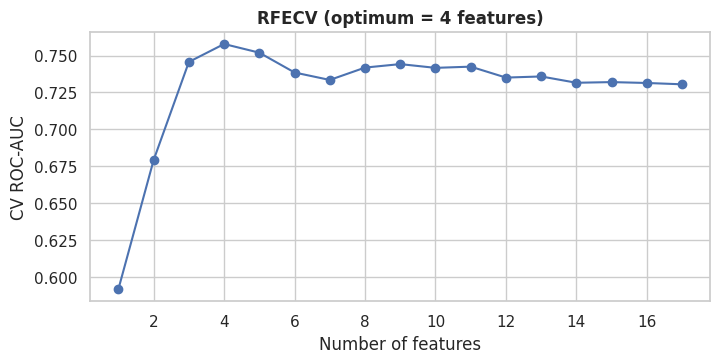

In [21]:
# ============================================================
# Section 9: Feature Selection Analysis
# ============================================================
# 9.0 Analysis matrix: engineered features, log1p on skewed, median-imputed, zero-variance removed
X_fe = engineer_features(X_model)
X_fs = SkewLogTransformer().fit(X_fe).transform(X_fe)
X_fs = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_fs), columns=X_fs.columns, index=X_fs.index)
X_fs = X_fs.loc[:, X_fs.nunique() > 1]
X_fs_std = pd.DataFrame(StandardScaler().fit_transform(X_fs), columns=X_fs.columns, index=X_fs.index)
FS_FEATURES = list(X_fs.columns)
y_fs = y_model.values
fs_scores = pd.DataFrame(index=FS_FEATURES)

# 9.1 Filter methods
fs_scores["univariate_AUC"] = [uni_auc(y_fs, X_fs[c])[0] for c in FS_FEATURES]
fs_scores["chi2"] = chi2(MinMaxScaler().fit_transform(X_fs), y_fs)[0]
fs_scores["ANOVA_F"] = np.nan_to_num(f_classif(X_fs_std, y_fs)[0])
fs_scores["mutual_info"] = np.mean([mutual_info_classif(X_fs_std, y_fs, random_state=s) for s in range(5)], axis=0)

# 9.2 Correlation (redundancy) filter: for pairs with |Spearman| >= 0.85 drop the weaker feature
spear = X_fs.corr(method="spearman").abs()
CORR_DROP, redundant = set(), []
for i, a in enumerate(FS_FEATURES):
    for b in FS_FEATURES[i + 1:]:
        if spear.loc[a, b] >= 0.85:
            weaker = a if fs_scores.loc[a, "univariate_AUC"] < fs_scores.loc[b, "univariate_AUC"] else b
            redundant.append({"feature_a": a, "feature_b": b, "abs_spearman": spear.loc[a, b], "drop": weaker})
            CORR_DROP.add(weaker)
print("Redundant pairs (|Spearman| >= 0.85):")
display(pd.DataFrame(redundant) if redundant else "none")

# 9.3 Embedded: L1 (LASSO) logistic regression + stability selection
l1 = LogisticRegressionCV(Cs=np.logspace(-3, 1, 20), penalty="l1", solver="liblinear",
                          cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="roc_auc",
                          class_weight="balanced", max_iter=5000, random_state=SEED).fit(X_fs_std, y_fs)
fs_scores["LASSO_abs_coef"] = np.abs(l1.coef_.ravel())
best_C = float(l1.C_[0])
rng = np.random.default_rng(SEED)
freq = np.zeros(len(FS_FEATURES)); B = 100
for _ in range(B):
    idx = rng.choice(len(y_fs), size=len(y_fs) // 2, replace=False)
    m = LogisticRegression(penalty="l1", solver="liblinear", C=best_C, class_weight="balanced",
                           max_iter=5000).fit(X_fs_std.values[idx], y_fs[idx])
    freq += np.abs(m.coef_.ravel()) > 1e-8
fs_scores["L1_stability_freq"] = freq / B
print(f"LASSO best C = {best_C:.4f}; non-zero coefficients: {int((fs_scores['LASSO_abs_coef'] > 1e-8).sum())}/{len(FS_FEATURES)}")

# 9.4 Wrapper: RFECV with logistic regression
rfecv = RFECV(LogisticRegression(class_weight="balanced", max_iter=5000), step=1,
              cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="roc_auc",
              min_features_to_select=1, n_jobs=N_JOBS).fit(X_fs_std, y_fs)
fs_scores["RFECV_rank"] = rfecv.ranking_
rfe_scores = rfecv.cv_results_["mean_test_score"]
plt.figure(figsize=(8, 3.5))
plt.plot(np.arange(1, len(rfe_scores) + 1), rfe_scores, marker="o")
plt.xlabel("Number of features"); plt.ylabel("CV ROC-AUC"); plt.title(f"RFECV (optimum = {rfecv.n_features_} features)")
save_fig("rfecv_curve"); plt.show()

# 9.5 Tree-based impurity importance + out-of-fold permutation importance
et = ExtraTreesClassifier(n_estimators=500, min_samples_leaf=3, class_weight="balanced", n_jobs=N_JOBS,
                          random_state=SEED).fit(X_fs, y_fs)
fs_scores["ExtraTrees_impurity"] = et.feature_importances_
perm = np.zeros(len(FS_FEATURES))
for tr, va in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X_fs, y_fs):
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced_subsample",
                                n_jobs=N_JOBS, random_state=SEED).fit(X_fs.iloc[tr], y_fs[tr])
    pi = permutation_importance(rf, X_fs.iloc[va], y_fs[va], scoring="roc_auc", n_repeats=10,
                                random_state=SEED, n_jobs=N_JOBS)
    perm += pi.importances_mean / 5
fs_scores["Permutation_AUC_drop_OOF"] = perm

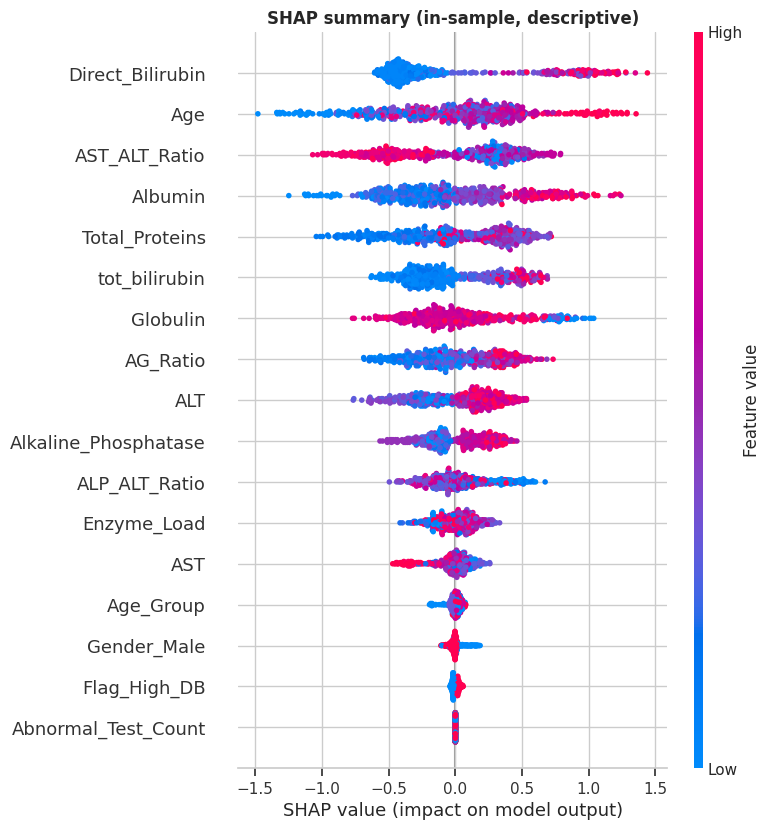

Boruta decisions: {'Confirmed': 8, 'Rejected': 8, 'Tentative': 1}


In [22]:
# 9.6 SHAP (model-explanation importance) with a gradient-boosting model
SHAP_OK = False
if shap is not None:
    try:
        shap_model = clone(tree_model()).fit(X_fs, y_fs)
        explainer = shap.TreeExplainer(shap_model)
        sv = explainer.shap_values(X_fs)
        if isinstance(sv, list):
            sv = sv[1]
        sv = np.asarray(sv)
        if sv.ndim == 3:
            sv = sv[:, :, 1]
        fs_scores["SHAP_mean_abs"] = np.abs(sv).mean(axis=0)
        shap.summary_plot(sv, X_fs, show=False, max_display=20)
        plt.title("SHAP summary (in-sample, descriptive)"); save_fig("shap_summary"); plt.show()
        SHAP_OK = True
    except Exception as exc:
        print(f"[WARN] SHAP skipped: {exc}")
else:
    print("[INFO] shap not available; skipping.")

# 9.7 Boruta (all-relevant selection with shadow features)
BORUTA_DECISION = None
if boruta is not None:
    try:
        from boruta import BorutaPy
        bor = BorutaPy(RandomForestClassifier(max_depth=5, class_weight="balanced", n_jobs=N_JOBS, random_state=SEED),
                       n_estimators="auto", max_iter=100, random_state=SEED, verbose=0)
        bor.fit(X_fs.values, y_fs)
        fs_scores["Boruta_rank"] = bor.ranking_
        BORUTA_DECISION = pd.Series(np.where(bor.support_, "Confirmed", np.where(bor.support_weak_, "Tentative", "Rejected")),
                                    index=FS_FEATURES, name="Boruta")
        print("Boruta decisions:", BORUTA_DECISION.value_counts().to_dict())
    except Exception as exc:
        print(f"[WARN] Boruta skipped: {exc}")
else:
    print("[INFO] Boruta not available; skipping.")

,univariate_AUC,chi2,ANOVA_F,mutual_info,LASSO_abs_coef,L1_stability_freq,RFECV_rank,ExtraTrees_impurity,Permutation_AUC_drop_OOF,SHAP_mean_abs,Boruta_rank,consensus_mean_rank,rank_sd,corr_filter,Boruta
Direct_Bilirubin,0.6933,16.0053,61.3298,0.0730,0.6483,0.9200,1,0.1015,0.0163,0.5050,1,2.0000,1.2450,drop (redundant),Confirmed
Albumin,0.6853,5.0471,50.7362,0.0688,0.4107,0.9800,6,0.0758,0.0122,0.3791,1,4.2273,2.2734,keep,Confirmed
AG_Ratio,0.6980,5.2040,57.0456,0.0611,0.1937,0.8100,10,0.0758,0.0106,0.2536,1,5.2273,3.0444,keep,Confirmed
Total_Proteins,0.6748,1.8796,33.1247,0.0226,0.1685,0.8600,1,0.0639,0.0138,0.3448,1,5.3636,2.0987,keep,Confirmed
tot_bilirubin,0.7008,10.4563,60.0860,0.0535,0.0000,0.3900,9,0.0947,0.0113,0.2890,1,5.5000,3.8665,keep,Confirmed
Age,0.5825,0.8148,11.0422,0.0502,0.2178,0.9600,1,0.0557,0.0095,0.4099,1,6.6364,4.5612,keep,Confirmed
AST_ALT_Ratio,0.6420,1.1085,26.6218,0.0219,0.1882,0.8400,8,0.0467,-0.0017,0.3903,1,8.2273,3.9202,keep,Confirmed
Flag_High_DB,0.6588,25.0725,51.4257,0.0277,0.0000,0.4500,13,0.0780,0.0021,0.0172,3,8.6818,4.8439,drop (redundant),Rejected
Abnormal_Test_Count,0.6588,25.0725,51.4257,0.0349,0.0000,0.4200,12,0.0679,0.0031,0.0000,3,8.7727,4.5846,drop (redundant),Rejected
Globulin,0.5673,0.0823,1.9519,0.0411,0.0000,0.0100,1,0.0619,0.0073,0.2735,1,10.0000,5.1527,keep,Confirmed


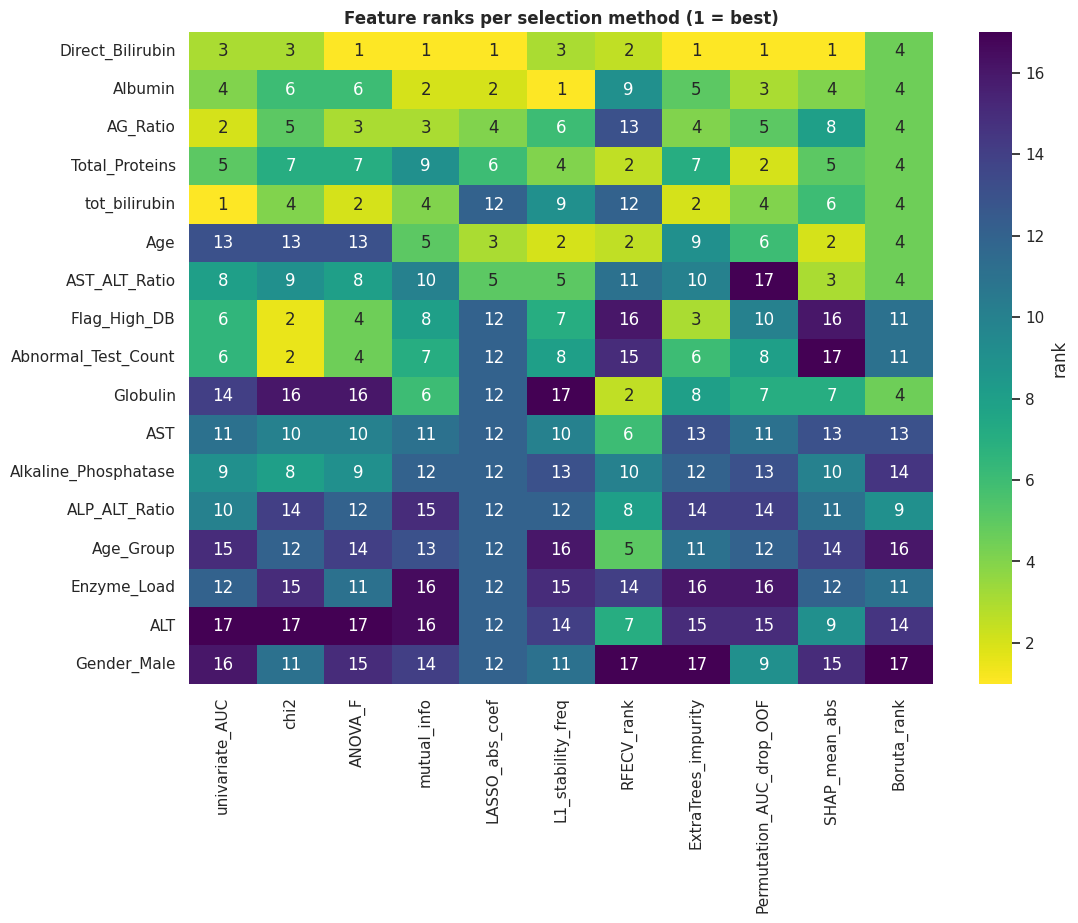

Consensus top-10: ['Direct_Bilirubin', 'Albumin', 'AG_Ratio', 'Total_Proteins', 'tot_bilirubin', 'Age', 'AST_ALT_Ratio', 'Flag_High_DB', 'Abnormal_Test_Count', 'Globulin']


In [23]:
# 9.8 Consensus ranking across all methods (rank 1 = most important)
ranks = pd.DataFrame(index=FS_FEATURES)
for col in fs_scores.columns:
    ranks[col] = fs_scores[col].rank(method="average") if col.endswith("_rank") else fs_scores[col].rank(ascending=False, method="average")
fs_summary = fs_scores.copy()
fs_summary["consensus_mean_rank"] = ranks.mean(axis=1)
fs_summary["rank_sd"] = ranks.std(axis=1)
fs_summary["corr_filter"] = ["drop (redundant)" if c in CORR_DROP else "keep" for c in FS_FEATURES]
if BORUTA_DECISION is not None:
    fs_summary["Boruta"] = BORUTA_DECISION
fs_summary = fs_summary.sort_values("consensus_mean_rank")
display(fs_summary)

plt.figure(figsize=(12, 0.38 * len(FS_FEATURES) + 2))
sns.heatmap(ranks.loc[fs_summary.index], annot=True, fmt=".0f", cmap="viridis_r", cbar_kws={"label": "rank"})
plt.title("Feature ranks per selection method (1 = best)"); save_fig("feature_rank_heatmap"); plt.show()

CONSENSUS_TOP = fs_summary.index[:10].tolist()
AUDIT["consensus_top_features"] = CONSENSUS_TOP
AUDIT["redundant_features_by_corr_filter"] = sorted(CORR_DROP)
print("Consensus top-10:", CONSENSUS_TOP)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

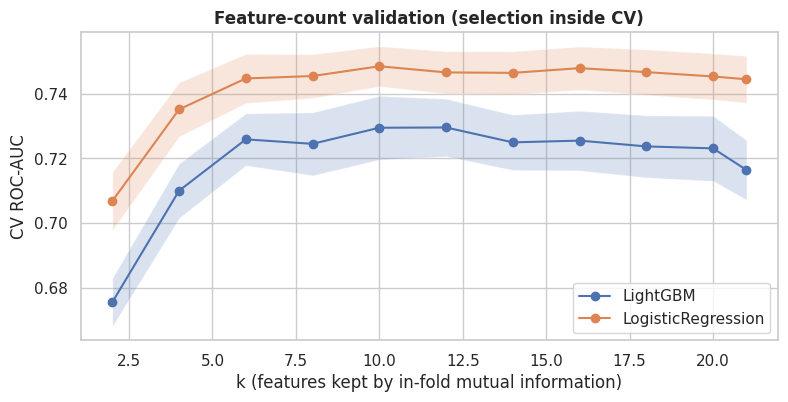

LightGBM: best AUC 0.730 at k=12; 1-SE rule -> k=6
LogisticRegression: best AUC 0.749 at k=10; 1-SE rule -> k=6


In [24]:
# 9.9 Leakage-free validation: how many features? (SelectKBest(MI) fitted inside each CV fold)
n_total = engineer_features(X_model).shape[1]
k_grid = sorted(set(list(range(2, n_total + 1, 2)) + [n_total]))
mi_score = partial(mutual_info_classif, random_state=SEED)
curve = []
for k in k_grid:
    for mname, mfn in [("LogisticRegression", linear_model), (TREE_NAME, tree_model)]:
        pipe = make_pipeline_(mfn(), fe=True, selector=SelectKBest(mi_score, k=k))
        res = cross_validate(pipe, X_model, y_model, cv=CV, scoring="roc_auc", n_jobs=N_JOBS)
        curve.append({"k": k, "model": mname, "auc": res["test_score"].mean(),
                      "se": res["test_score"].std() / np.sqrt(len(res["test_score"]))})
curve_df = pd.DataFrame(curve)

plt.figure(figsize=(9, 4))
for mname, g in curve_df.groupby("model"):
    plt.plot(g["k"], g["auc"], marker="o", label=mname)
    plt.fill_between(g["k"], g["auc"] - g["se"], g["auc"] + g["se"], alpha=0.2)
plt.xlabel("k (features kept by in-fold mutual information)"); plt.ylabel("CV ROC-AUC")
plt.title("Feature-count validation (selection inside CV)"); plt.legend(); save_fig("k_selection_curve"); plt.show()

# One-standard-error rule: smallest k within 1 SE of the best
FS_BEST_K = {}
for mname, g in curve_df.groupby("model"):
    best = g.loc[g["auc"].idxmax()]
    FS_BEST_K[mname] = int(g[g["auc"] >= best["auc"] - best["se"]]["k"].min())
    print(f"{mname}: best AUC {best['auc']:.3f} at k={int(best['k'])}; 1-SE rule -> k={FS_BEST_K[mname]}")
AUDIT["feature_count_1se"] = FS_BEST_K

### Recommended feature selection strategy
1. **Do not select on the full dataset.** With ~580 patients, full-data selection followed by CV is a classic source of optimistic bias. Any selector must live inside the pipeline (or be run in the inner loop of nested CV).
2. **Redundancy first:** bilirubin (total/direct), ALT/AST and albumin/total protein/A-G ratio form correlated clusters. For linear models keep one representative per cluster or rely on L1/L2 regularization; tree ensembles tolerate redundancy.
3. **Primary tool:** the consensus of stability-selected L1, out-of-fold permutation importance and SHAP, cross-checked by Boruta (all-relevant). Features that are consistently low across methods and rejected by Boruta are safe to drop.
4. **Model-specific:** gradient-boosting models usually do best with all (or nearly all) features; logistic regression benefits from a compact, de-correlated subset (see the 1-SE `k` above).
5. Because the dataset has only ~10 original features, aggressive selection rarely improves accuracy; its main value is **simpler, more interpretable and more stable** models.

## Section 10 — Data Preprocessing Pipeline Recommendation
The imputer choice is validated by downstream CV performance (what ultimately matters), and the full recommended pipeline is shown.

In [25]:
# ============================================================
# Section 10: Preprocessing Pipeline Recommendation
# ============================================================
imp_names = ["Median", "KNN (k=5)", "Iterative (BayesianRidge)"]
if BEST_IMPUTER_MASKING not in imp_names:
    imp_names.append(BEST_IMPUTER_MASKING)
imp_rows = []
for iname in imp_names:
    for mname, mfn in [("LogisticRegression", linear_model), (TREE_NAME, tree_model)]:
        res = cv_evaluate(make_pipeline_(mfn(), imputer=get_imputer(iname)), X_model, y_model)
        imp_rows.append({"imputer": iname, "model": mname, **res})
imp_df = pd.DataFrame(imp_rows).set_index(["imputer", "model"])
display(fmt_results(imp_df, ["roc_auc", "balanced_accuracy", "mcc"]))

imp_auc = imp_df.groupby(level="imputer")["roc_auc"].mean().sort_values(ascending=False)
FINAL_IMPUTER_NAME = imp_auc.index[0]
if imp_auc.get("Median", -1) >= imp_auc.iloc[0] - 0.005:      # prefer the simplest when differences are negligible
    FINAL_IMPUTER_NAME = "Median"
FINAL_IMPUTER = get_imputer(FINAL_IMPUTER_NAME)
AUDIT["final_imputer"] = FINAL_IMPUTER_NAME
print(f"Selected imputer: {FINAL_IMPUTER_NAME} (mean ROC-AUC over models: {imp_auc.round(4).to_dict()})")

PIPELINE_SPEC = pd.DataFrame([
    ("0. Deduplication", f"drop {len(df) - len(df_model)} exact duplicate rows before splitting", "no identical patients in train and test"),
    ("1. Encoding", "Gender -> Gender_Male (0/1)", "single binary categorical; one-hot unnecessary"),
    ("2. Deterministic repair", "A/G = Albumin / (Total_Proteins - Albumin) when missing" if AG_DETERMINISTIC else "not applicable",
     "exact recovery beats statistical estimation"),
    ("3. Feature engineering", ", ".join(NEW_FEATURES), "stateless, clinically motivated, fold-safe"),
    ("4. Transformation", "log1p on right-skewed non-negative features (learned per training fold)", "tames extreme but valid lab values"),
    ("5. Scaling", "RobustScaler (median / IQR)", "needed by LR/SVM/KNN; robust to extremes; harmless for trees"),
    ("6. Imputation", FINAL_IMPUTER_NAME + " (fitted on training fold)", "missingness is tiny; simplest adequate method"),
    ("7. Feature selection", f"in-fold; 1-SE k: {FS_BEST_K}", "trees: keep ~all; LR: compact de-correlated subset"),
    ("8. Balancing", "decided in Section 11 (training folds only)", "never resample before splitting"),
], columns=["step", "choice", "rationale"])
display(PIPELINE_SPEC)

RECOMMENDED_PIPELINE = make_pipeline_(linear_model(), imputer=FINAL_IMPUTER)
display(RECOMMENDED_PIPELINE)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

roc_auc balanced_accuracy            mcc
imputer                   model                                                             
Median                    LogisticRegression  0.745 ± 0.028     0.690 ± 0.029  0.347 ± 0.054
                          LightGBM            0.716 ± 0.036     0.634 ± 0.059  0.254 ± 0.110
KNN (k=5)                 LogisticRegression  0.746 ± 0.028     0.691 ± 0.030  0.349 ± 0.055
                          LightGBM            0.719 ± 0.034     0.620 ± 0.052  0.228 ± 0.096
Iterative (BayesianRidge) LogisticRegression  0.746 ± 0.028     0.692 ± 0.029  0.351 ± 0.055
                          LightGBM            0.719 ± 0.034     0.625 ± 0.054  0.239 ± 0.102

Selected imputer: Median (mean ROC-AUC over models: {'Iterative (BayesianRidge)': 0.7324, 'KNN (k=5)': 0.7322, 'Median': 0.7305})


,step,choice,rationale
0,0. Deduplication,drop 13 exact duplicate rows before splitting,no identical patients in train and test
1,1. Encoding,Gender -> Gender_Male (0/1),single binary categorical; one-hot unnecessary
2,2. Deterministic repair,not applicable,exact recovery beats statistical estimation
3,3. Feature engineering,"Globulin, AST_ALT_Ratio, ALP_ALT_Ratio, Enzyme...","stateless, clinically motivated, fold-safe"
4,4. Transformation,log1p on right-skewed non-negative features (l...,tames extreme but valid lab values
5,5. Scaling,RobustScaler (median / IQR),needed by LR/SVM/KNN; robust to extremes; harm...
6,6. Imputation,Median (fitted on training fold),missingness is tiny; simplest adequate method
7,7. Feature selection,"in-fold; 1-SE k: {'LightGBM': 6, 'LogisticRegr...",trees: keep ~all; LR: compact de-correlated su...
8,8. Balancing,decided in Section 11 (training folds only),never resample before splitting


Pipeline(steps=[('features',
                 FunctionTransformer(func=<function engineer_features at 0x7e5732ecc9a0>)),
                ('log_skewed', SkewLogTransformer()), ('scale', RobustScaler()),
                ('impute', SimpleImputer(strategy='median')),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    random_state=42))])

## Section 11 — Class Imbalance Strategy
All strategies are compared under identical repeated stratified CV with resampling **inside** the training folds only.

| Method | Idea | Risk on ILPD |
|---|---|---|
| Class weights | re-weight the loss; no new samples | none (preferred baseline) |
| RandomOverSampler | duplicate minority rows | overfitting to duplicated patients |
| SMOTE | interpolate between minority neighbours | synthetic "patients" in overlapping regions |
| Borderline-SMOTE | SMOTE focused near the boundary | amplifies label noise where classes overlap heavily |
| ADASYN | more synthesis for hard minority points | same, stronger |
| SMOTE-Tomek / SMOTEENN | oversample then clean boundary | ENN can delete many real samples on a small dataset |
| RandomUnderSampler | drop majority rows | discards ~40% of disease cases |

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

roc_auc         pr_auc       accuracy balanced_accuracy    sensitivity    specificity             f1            mcc
strategy            model                                                                                                                                        
None (no balancing) LogisticRegression  0.744 ± 0.028  0.894 ± 0.012  0.709 ± 0.029     0.581 ± 0.036  0.883 ± 0.037  0.278 ± 0.073  0.812 ± 0.021  0.199 ± 0.082
                    LightGBM            0.714 ± 0.038  0.877 ± 0.019  0.697 ± 0.028     0.594 ± 0.038  0.837 ± 0.037  0.350 ± 0.084  0.797 ± 0.021  0.205 ± 0.081
Class weights       LogisticRegression  0.745 ± 0.028  0.894 ± 0.012  0.649 ± 0.029     0.690 ± 0.029  0.592 ± 0.054  0.789 ± 0.079  0.705 ± 0.034  0.347 ± 0.054
                    LightGBM            0.716 ± 0.036  0.879 ± 0.017  0.675 ± 0.042     0.634 ± 0.059  0.732 ± 0.048  0.535 ± 0.120  0.762 ± 0.033  0.254 ± 0.110
RandomOverSampler   LogisticRegression  0.745 ± 0.026  0.894 ± 0.010  0.646 ± 0.028     0.688 ± 0.030  0.589 ± 0.054  0.787 ± 0.084  0.702 ± 0.034  0.343 ± 0.056
                    LightGBM            0.711 ± 0.040  0.877 ± 0.019  0.672 ± 0.037     0.612 ± 0.048  0.753 ± 0.048  0.472 ± 0.100  0.765 ± 0.029  0.220 ± 0.093
SMOTE               LogisticRegression  0.743 ± 0.034  0.893 ± 0.013  0.651 ± 0.028     0.691 ± 0.030  0.599 ± 0.049  0.783 ± 0.078  0.709 ± 0.031  0.347 ± 0.056
                    LightGBM            0.720 ± 0.045  0.879 ± 0.022  0.682 ± 0.041     0.630 ± 0.051  0.754 ± 0.039  0.506 ± 0.088  0.772 ± 0.031  0.252 ± 0.096
Borderline-SMOTE    LogisticRegression  0.745 ± 0.029  0.894 ± 0.012  0.655 ± 0.030     0.699 ± 0.034  0.595 ± 0.051  0.803 ± 0.081  0.710 ± 0.033  0.363 ± 0.063
                    LightGBM            0.733 ± 0.038  0.885 ± 0.019  0.687 ± 0.030     0.632 ± 0.036  0.761 ± 0.040  0.503 ± 0.074  0.775 ± 0.025  0.258 ± 0.069
ADASYN              LogisticRegression  0.741 ± 0.034  0.892 ± 0.014  0.637 ± 0.028     0.688 ± 0.034  0.569 ± 0.056  0.807 ± 0.096  0.689 ± 0.035  0.345 ± 0.065
                    LightGBM            0.730 ± 0.046  0.883 ± 0.023  0.693 ± 0.036     0.646 ± 0.053  0.757 ± 0.039  0.535 ± 0.108  0.778 ± 0.026  0.281 ± 0.098
SMOTE-Tomek         LogisticRegression  0.744 ± 0.034  0.893 ± 0.013  0.647 ± 0.026     0.687 ± 0.028  0.594 ± 0.050  0.781 ± 0.078  0.705 ± 0.031  0.341 ± 0.051
                    LightGBM            0.721 ± 0.044  0.876 ± 0.025  0.682 ± 0.041     0.628 ± 0.051  0.757 ± 0.046  0.498 ± 0.094  0.772 ± 0.032  0.249 ± 0.097
SMOTEENN            LogisticRegression  0.746 ± 0.031  0.893 ± 0.012  0.619 ± 0.037     0.697 ± 0.031  0.514 ± 0.057  0.880 ± 0.062  0.656 ± 0.045  0.366 ± 0.058
                    LightGBM            0.723 ± 0.036  0.876 ± 0.015  0.630 ± 0.039     0.675 ± 0.036  0.569 ± 0.057  0.780 ± 0.067  0.685 ± 0.043  0.319 ± 0.065
RandomUnderSampler  LogisticRegression  0.745 ± 0.029  0.893 ± 0.012  0.644 ± 0.030     0.691 ± 0.028  0.581 ± 0.053  0.801 ± 0.072  0.698 ± 0.035  0.348 ± 0.052
                    LightGBM            0.718 ± 0.037  0.873 ± 0.020  0.643 ± 0.031     0.670 ± 0.032  0.608 ± 0.048  0.732 ± 0.070  0.707 ± 0.033  0.309 ± 0.059

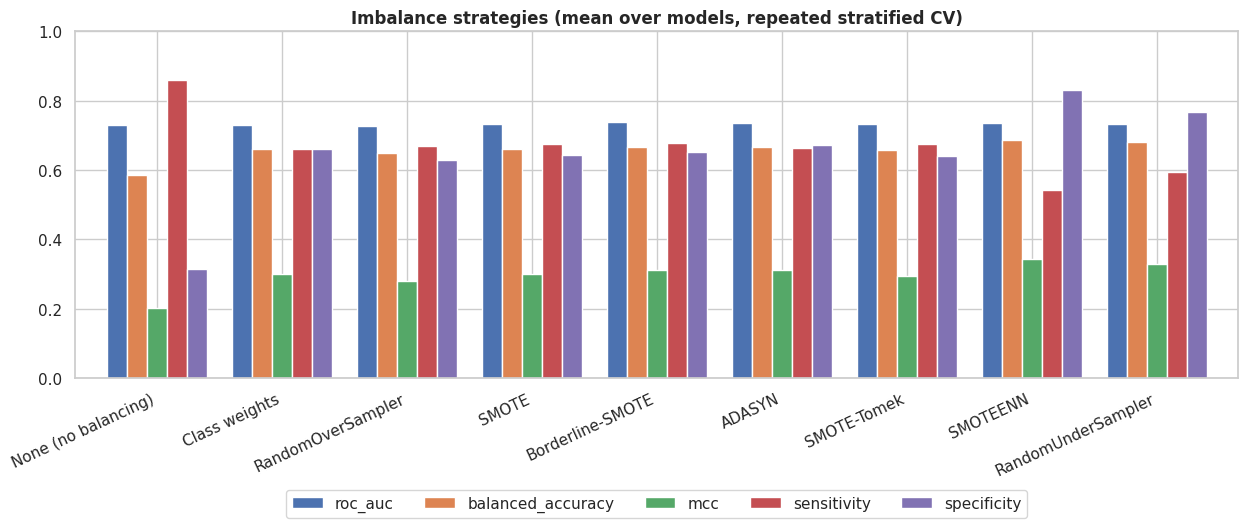

Recommended balancing strategy: SMOTEENN
Note: ROC-AUC barely moves across strategies (ranking is unchanged); balancing mostly shifts the sensitivity/specificity trade-off, which threshold tuning can also do.


In [26]:
# ============================================================
# Section 11: Class Imbalance Strategy
# ============================================================
strategies = OrderedDict([("None (no balancing)", (None, False)), ("Class weights", (None, True))])
if imblearn is not None:
    strategies.update([
        ("RandomOverSampler", (RandomOverSampler(random_state=SEED), False)),
        ("SMOTE", (SMOTE(random_state=SEED), False)),
        ("Borderline-SMOTE", (BorderlineSMOTE(random_state=SEED), False)),
        ("ADASYN", (ADASYN(random_state=SEED), False)),
        ("SMOTE-Tomek", (SMOTETomek(random_state=SEED), False)),
        ("SMOTEENN", (SMOTEENN(random_state=SEED), False)),
        ("RandomUnderSampler", (RandomUnderSampler(random_state=SEED), False)),
    ])

imb_rows = []
for sname, (sampler, weighted) in strategies.items():
    for mname, mfn in [("LogisticRegression", linear_model), (TREE_NAME, tree_model)]:
        try:
            pipe = make_pipeline_(mfn(balanced=weighted), imputer=FINAL_IMPUTER,
                                  sampler=clone(sampler) if sampler is not None else None)
            imb_rows.append({"strategy": sname, "model": mname, **cv_evaluate(pipe, X_model, y_model)})
        except Exception as exc:
            print(f"[WARN] {sname} / {mname} failed: {exc}")
imb_df = pd.DataFrame(imb_rows).set_index(["strategy", "model"])
display(fmt_results(imb_df))

strat_mean = imb_df.groupby(level="strategy", sort=False)[["roc_auc", "balanced_accuracy", "mcc", "sensitivity", "specificity", "accuracy"]].mean()
ax = strat_mean[["roc_auc", "balanced_accuracy", "mcc", "sensitivity", "specificity"]].plot.bar(figsize=(15, 4.5), width=0.8)
ax.set_ylim(0, 1); ax.set_xlabel(""); ax.set_title("Imbalance strategies (mean over models, repeated stratified CV)")
plt.xticks(rotation=25, ha="right"); plt.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.3))
save_fig("imbalance_strategies"); plt.show()

# Decision rule: best balanced accuracy; prefer class weights if within 0.01 (no synthetic data)
best_ba = strat_mean["balanced_accuracy"].max()
contenders = strat_mean[strat_mean["balanced_accuracy"] >= best_ba - 0.01]
IMB_CHOICE = "Class weights" if "Class weights" in contenders.index else contenders["roc_auc"].idxmax()
AUDIT["imbalance_strategy"] = IMB_CHOICE
AUDIT["imbalance_table"] = strat_mean.round(4).to_dict(orient="index")
print(f"Recommended balancing strategy: {IMB_CHOICE}")
print("Note: ROC-AUC barely moves across strategies (ranking is unchanged); balancing mostly shifts the "
      "sensitivity/specificity trade-off, which threshold tuning can also do.")

,accuracy,roc_auc
"WRONG: SMOTE on full data, then CV",0.8161,0.9067
RIGHT: SMOTE inside training folds,0.6965,0.7316


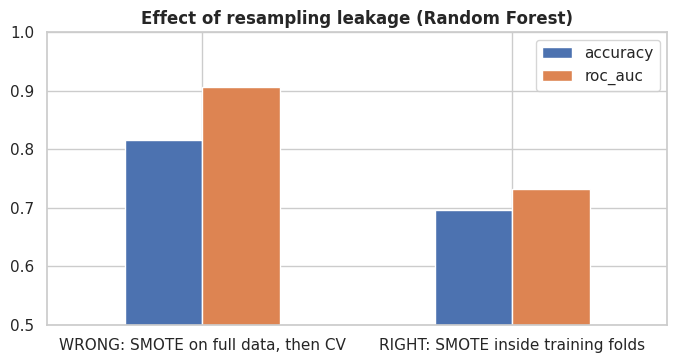

The inflated 'WRONG' numbers come from synthetic neighbours of test points being in the training folds. This is the most common reason ILPD papers report 90%+ accuracy.


In [27]:
# 11.2 Leakage demonstration: SMOTE BEFORE splitting (wrong) vs inside the pipeline (right)
if imblearn is not None:
    pre = SkPipeline(make_pipeline_(linear_model(), imputer=FINAL_IMPUTER).steps[:-1])
    Xt = pre.fit_transform(X_model, y_model)
    Xs, ys = SMOTE(random_state=SEED).fit_resample(Xt, y_model)
    rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=1)
    wrong = cross_validate(rf, Xs, ys, cv=CV, scoring=["accuracy", "roc_auc"], n_jobs=N_JOBS)
    right = cross_validate(make_pipeline_(clone(rf), imputer=FINAL_IMPUTER, sampler=SMOTE(random_state=SEED)),
                           X_model, y_model, cv=CV, scoring=["accuracy", "roc_auc"], n_jobs=N_JOBS)
    leak = pd.DataFrame({"accuracy": [wrong["test_accuracy"].mean(), right["test_accuracy"].mean()],
                         "roc_auc": [wrong["test_roc_auc"].mean(), right["test_roc_auc"].mean()]},
                        index=["WRONG: SMOTE on full data, then CV", "RIGHT: SMOTE inside training folds"])
    display(leak)
    leak.plot.bar(figsize=(8, 3.8), rot=0, ylim=(0.5, 1.0)); plt.title("Effect of resampling leakage (Random Forest)")
    save_fig("leakage_demo"); plt.show()
    AUDIT["leakage_demo"] = leak.round(4).to_dict(orient="index")
    print("The inflated 'WRONG' numbers come from synthetic neighbours of test points being in the training folds. "
          "This is the most common reason ILPD papers report 90%+ accuracy.")

## Section 12 — Model Selection Recommendation
A **screening** benchmark with sensible, regularized defaults (no tuning) to identify which model families deserve hyperparameter optimization. With ~570 samples and ~20 features, shallow and regularized models are favoured; deep networks are not appropriate here.

In [28]:
# ============================================================
# Section 12: Model Screening (default, regularized hyperparameters; class weights)
# ============================================================
def get_models(y):
    n_pos, n_neg = int((y == 1).sum()), int((y == 0).sum())
    spw = n_neg / max(n_pos, 1)                      # positive class (disease) is the majority here
    models = OrderedDict()
    models["LogisticRegression"] = linear_model()
    models["SVM-RBF"] = SVC(C=1.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED)
    models["RandomForest"] = RandomForestClassifier(n_estimators=500, min_samples_leaf=3, class_weight="balanced_subsample",
                                                    n_jobs=1, random_state=SEED)
    models["ExtraTrees"] = ExtraTreesClassifier(n_estimators=500, min_samples_leaf=3, class_weight="balanced",
                                                n_jobs=1, random_state=SEED)
    models["GradientBoosting"] = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                                            subsample=0.8, random_state=SEED)  # no class_weight support
    try:
        models["HistGradientBoosting"] = HistGradientBoostingClassifier(learning_rate=0.05, max_depth=3, max_iter=300,
                                                                        l2_regularization=1.0, class_weight="balanced",
                                                                        random_state=SEED)
    except TypeError:
        models["HistGradientBoosting"] = HistGradientBoostingClassifier(learning_rate=0.05, max_depth=3, max_iter=300,
                                                                        l2_regularization=1.0, random_state=SEED)
    if xgb is not None:
        models["XGBoost"] = xgb.XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=3, subsample=0.8,
                                              colsample_bytree=0.8, min_child_weight=2, reg_lambda=1.0,
                                              scale_pos_weight=spw, eval_metric="logloss", n_jobs=1, random_state=SEED)
    if lgb is not None:
        models["LightGBM"] = tree_model()
    if cb is not None:
        models["CatBoost"] = cb.CatBoostClassifier(iterations=500, learning_rate=0.03, depth=4, l2_leaf_reg=5,
                                                   auto_class_weights="Balanced", random_seed=SEED, verbose=0,
                                                   thread_count=1, allow_writing_files=False)
    return models

MODELS = get_models(y_model)
BENCH_PIPES, bench_rows = OrderedDict(), OrderedDict()
for name, model in MODELS.items():
    pipe = make_pipeline_(model, imputer=FINAL_IMPUTER)
    try:
        bench_rows[name] = cv_evaluate(pipe, X_model, y_model)
        BENCH_PIPES[name] = pipe
        print(f"  {name:<22} ROC-AUC {bench_rows[name]['roc_auc']:.3f} | balanced acc {bench_rows[name]['balanced_accuracy']:.3f}")
    except Exception as exc:
        print(f"[WARN] {name} failed and is skipped: {type(exc).__name__}: {exc}")
bench_df = pd.DataFrame(bench_rows).T.sort_values("roc_auc", ascending=False)
display(fmt_results(bench_df))

  LogisticRegression     ROC-AUC 0.745 | balanced acc 0.690
  SVM-RBF                ROC-AUC 0.756 | balanced acc 0.691
  RandomForest           ROC-AUC 0.737 | balanced acc 0.633
  ExtraTrees             ROC-AUC 0.752 | balanced acc 0.687
  GradientBoosting       ROC-AUC 0.714 | balanced acc 0.582
  HistGradientBoosting   ROC-AUC 0.717 | balanced acc 0.635
  XGBoost                ROC-AUC 0.729 | balanced acc 0.662


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  LightGBM               ROC-AUC 0.716 | balanced acc 0.634
  CatBoost               ROC-AUC 0.716 | balanced acc 0.636


,roc_auc,pr_auc,accuracy,balanced_accuracy,sensitivity,specificity,f1,mcc
SVM-RBF,0.756 ± 0.032,0.893 ± 0.015,0.628 ± 0.025,0.691 ± 0.022,0.543 ± 0.045,0.839 ± 0.056,0.674 ± 0.031,0.351 ± 0.041
ExtraTrees,0.752 ± 0.028,0.896 ± 0.012,0.670 ± 0.034,0.687 ± 0.039,0.646 ± 0.046,0.727 ± 0.078,0.735 ± 0.032,0.341 ± 0.070
LogisticRegression,0.745 ± 0.028,0.894 ± 0.012,0.649 ± 0.029,0.690 ± 0.029,0.592 ± 0.054,0.789 ± 0.079,0.705 ± 0.034,0.347 ± 0.054
RandomForest,0.737 ± 0.030,0.889 ± 0.014,0.699 ± 0.033,0.633 ± 0.054,0.789 ± 0.025,0.478 ± 0.111,0.789 ± 0.021,0.265 ± 0.099
XGBoost,0.729 ± 0.038,0.884 ± 0.017,0.668 ± 0.028,0.662 ± 0.041,0.677 ± 0.043,0.648 ± 0.096,0.744 ± 0.025,0.299 ± 0.072
HistGradientBoosting,0.717 ± 0.037,0.881 ± 0.018,0.661 ± 0.033,0.635 ± 0.048,0.697 ± 0.036,0.573 ± 0.098,0.746 ± 0.026,0.252 ± 0.087
LightGBM,0.716 ± 0.036,0.879 ± 0.017,0.675 ± 0.042,0.634 ± 0.059,0.732 ± 0.048,0.535 ± 0.120,0.762 ± 0.033,0.254 ± 0.110
CatBoost,0.716 ± 0.034,0.882 ± 0.015,0.667 ± 0.035,0.636 ± 0.046,0.709 ± 0.042,0.563 ± 0.092,0.752 ± 0.029,0.256 ± 0.083
GradientBoosting,0.714 ± 0.040,0.877 ± 0.018,0.691 ± 0.028,0.582 ± 0.044,0.837 ± 0.034,0.327 ± 0.100,0.794 ± 0.019,0.180 ± 0.093


Ensemble members: ['SVM-RBF', 'ExtraTrees', 'LogisticRegression']


,roc_auc,pr_auc,accuracy,balanced_accuracy,sensitivity,specificity,f1,mcc
SoftVoting,0.758 ± 0.027,0.898 ± 0.010,0.687 ± 0.036,0.687 ± 0.040,0.686 ± 0.050,0.687 ± 0.080,0.756 ± 0.033,0.344 ± 0.073
SVM-RBF,0.756 ± 0.032,0.893 ± 0.015,0.628 ± 0.025,0.691 ± 0.022,0.543 ± 0.045,0.839 ± 0.056,0.674 ± 0.031,0.351 ± 0.041
Stacking(LR meta),0.753 ± 0.026,0.897 ± 0.010,0.656 ± 0.028,0.697 ± 0.024,0.599 ± 0.052,0.795 ± 0.068,0.711 ± 0.033,0.359 ± 0.045
ExtraTrees,0.752 ± 0.028,0.896 ± 0.012,0.670 ± 0.034,0.687 ± 0.039,0.646 ± 0.046,0.727 ± 0.078,0.735 ± 0.032,0.341 ± 0.070
LogisticRegression,0.745 ± 0.028,0.894 ± 0.012,0.649 ± 0.029,0.690 ± 0.029,0.592 ± 0.054,0.789 ± 0.079,0.705 ± 0.034,0.347 ± 0.054
RandomForest,0.737 ± 0.030,0.889 ± 0.014,0.699 ± 0.033,0.633 ± 0.054,0.789 ± 0.025,0.478 ± 0.111,0.789 ± 0.021,0.265 ± 0.099
XGBoost,0.729 ± 0.038,0.884 ± 0.017,0.668 ± 0.028,0.662 ± 0.041,0.677 ± 0.043,0.648 ± 0.096,0.744 ± 0.025,0.299 ± 0.072
HistGradientBoosting,0.717 ± 0.037,0.881 ± 0.018,0.661 ± 0.033,0.635 ± 0.048,0.697 ± 0.036,0.573 ± 0.098,0.746 ± 0.026,0.252 ± 0.087
LightGBM,0.716 ± 0.036,0.879 ± 0.017,0.675 ± 0.042,0.634 ± 0.059,0.732 ± 0.048,0.535 ± 0.120,0.762 ± 0.033,0.254 ± 0.110
CatBoost,0.716 ± 0.034,0.882 ± 0.015,0.667 ± 0.035,0.636 ± 0.046,0.709 ± 0.042,0.563 ± 0.092,0.752 ± 0.029,0.256 ± 0.083


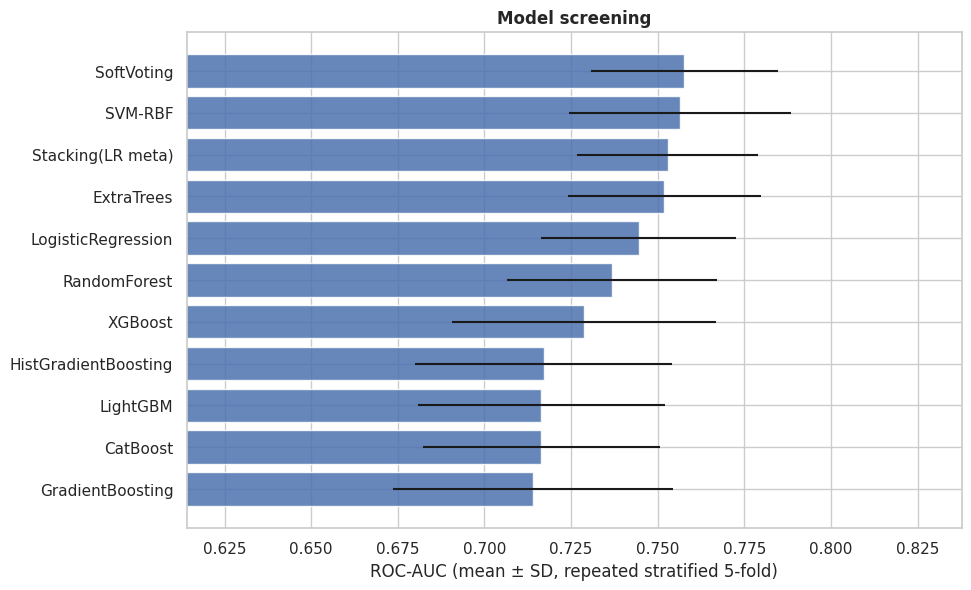

In [29]:
# 12.2 Ensembles built from the strongest (and a linear) base models
top_members = bench_df.index[:3].tolist()
if "LogisticRegression" not in top_members and "LogisticRegression" in BENCH_PIPES:
    top_members.append("LogisticRegression")          # add model diversity
estimators = [(n, clone(BENCH_PIPES[n])) for n in top_members]
ensembles = OrderedDict([
    ("SoftVoting", VotingClassifier(estimators=estimators, voting="soft", n_jobs=1)),
    ("Stacking(LR meta)", StackingClassifier(estimators=estimators,
                                             final_estimator=LogisticRegression(class_weight="balanced", max_iter=5000),
                                             stack_method="predict_proba",
                                             cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=1)),
])
for name, ens in ensembles.items():
    try:
        bench_rows[name] = cv_evaluate(ens, X_model, y_model)
        BENCH_PIPES[name] = ens
    except Exception as exc:
        print(f"[WARN] {name} failed: {exc}")
bench_df = pd.DataFrame(bench_rows).T.sort_values("roc_auc", ascending=False)
print("Ensemble members:", top_members)
display(fmt_results(bench_df))

plt.figure(figsize=(10, 0.45 * len(bench_df) + 1.5))
plt.barh(bench_df.index[::-1], bench_df["roc_auc"][::-1], xerr=bench_df["roc_auc_sd"][::-1], color="#4C72B0", alpha=0.85)
plt.axvline(0.5, ls=":", c="grey"); plt.xlabel("ROC-AUC (mean ± SD, repeated stratified 5-fold)")
plt.xlim(max(0.4, bench_df["roc_auc"].min() - 0.1), min(1.0, bench_df["roc_auc"].max() + 0.08))
plt.title("Model screening"); save_fig("model_screening"); plt.show()

AUDIT["model_ranking_roc_auc"] = bench_df["roc_auc"].round(4).to_dict()
AUDIT["best_screening_model"] = bench_df.index[0]
AUDIT["best_screening_metrics"] = bench_df.iloc[0][MAIN_METRICS].round(4).to_dict()

### Recommended model families
- **Logistic regression (L1/L2/elastic-net) on log-transformed features** — mandatory baseline; on ILPD it is frequently within noise of the best model and is the most interpretable.
- **CatBoost / LightGBM / XGBoost** (shallow trees, strong regularization, class weights) — main candidates for tuning; CatBoost's ordered boosting is particularly robust on small data.
- **Random Forest / Extra Trees** — stable, low-variance ensemble members.
- **Soft voting / stacking** of 3–4 *diverse* models (one linear + boosted trees + bagged trees) — usually a small but consistent gain; use an out-of-fold meta-learner as done here.
- Tune with **nested CV** (e.g. Optuna in the inner loop, 50–100 trials) — tuning on the same folds used for reporting inflates results.

## Section 13 — Evaluation Strategy Recommendation
Out-of-fold predictions of the best screening model are evaluated with the full medical metric set, threshold analysis, bootstrap confidence intervals and calibration.

**Metrics:** Accuracy · Precision (PPV) · Recall = **Sensitivity** · **Specificity** · F1 · Balanced accuracy · MCC · ROC-AUC · PR-AUC · Brier score.

,threshold,accuracy,precision,sensitivity,specificity,f1,balanced_accuracy,mcc,roc_auc,pr_auc,brier
threshold 0.5,0.5000,0.6895,0.8418,0.6946,0.6768,0.7611,0.6857,0.3416,0.7503,0.8936,0.1818
Youden-optimal threshold*,0.5645,0.6667,0.8776,0.6182,0.7866,0.7254,0.7024,0.3665,0.7503,0.8936,0.1818


SoftVoting: OOF ROC-AUC 0.750 (95% bootstrap CI 0.707–0.790); balanced accuracy at Youden threshold 95% CI 0.663–0.741
*The Youden threshold is chosen on the same OOF predictions, so it is slightly optimistic; in the final framework select it inside the inner CV loop.


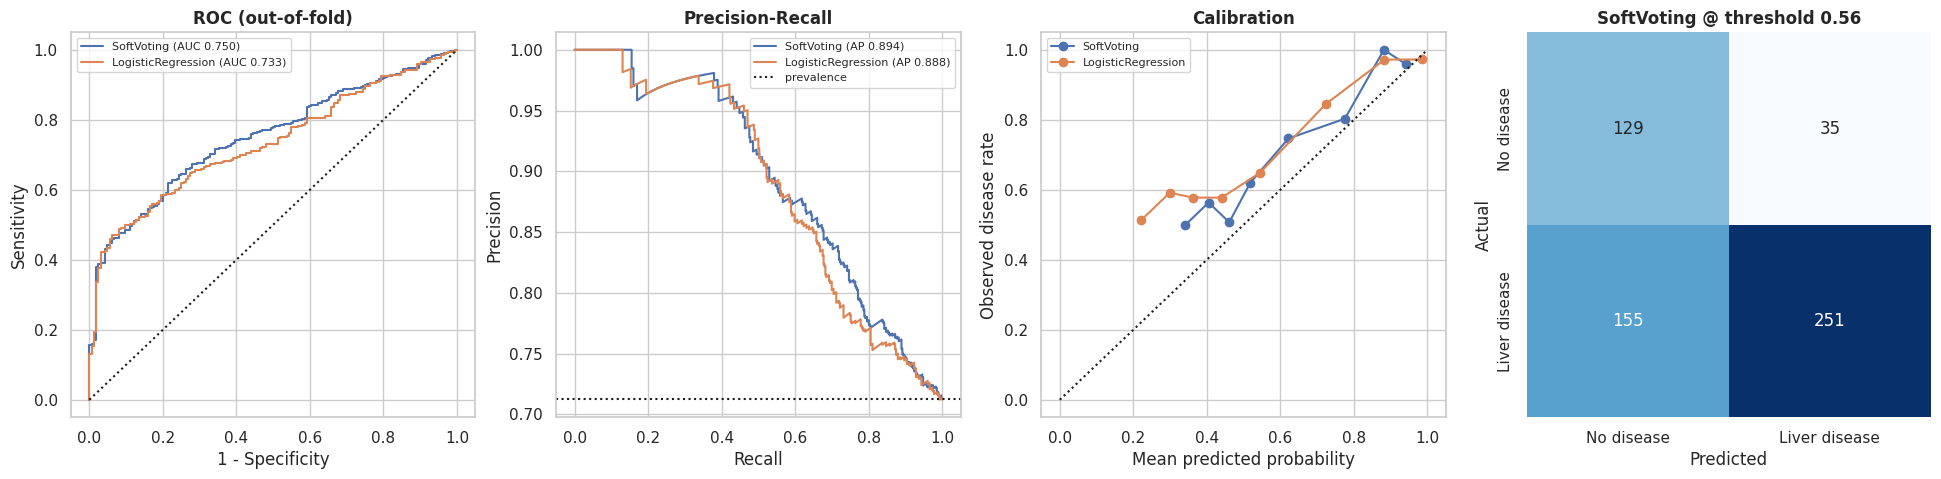

In [30]:
# ============================================================
# Section 13: Evaluation Strategy
# ============================================================
def compute_metrics(y_true, proba, thr=0.5):
    y_true = np.asarray(y_true); pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"threshold": thr, "accuracy": (tp + tn) / len(y_true),
            "precision": tp / (tp + fp) if tp + fp else 0.0,
            "sensitivity": tp / (tp + fn) if tp + fn else 0.0,
            "specificity": tn / (tn + fp) if tn + fp else 0.0,
            "f1": f1_score(y_true, pred, zero_division=0), "balanced_accuracy": balanced_accuracy_score(y_true, pred),
            "mcc": matthews_corrcoef(y_true, pred), "roc_auc": roc_auc_score(y_true, proba),
            "pr_auc": average_precision_score(y_true, proba), "brier": brier_score_loss(y_true, proba)}

def bootstrap_ci(y_true, proba, fn, n_boot=1000, seed=SEED):
    rng_ = np.random.default_rng(seed); y_true = np.asarray(y_true); proba = np.asarray(proba); vals = []
    for _ in range(n_boot):
        idx = rng_.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) == 2:
            vals.append(fn(y_true[idx], proba[idx]))
    return np.percentile(vals, [2.5, 97.5])

skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
BEST_NAME = bench_df.index[0]
eval_names = [BEST_NAME] + (["LogisticRegression"] if BEST_NAME != "LogisticRegression" and "LogisticRegression" in BENCH_PIPES else [])
OOF = {n: cross_val_predict(clone(BENCH_PIPES[n]), X_model, y_model, cv=skf, method="predict_proba", n_jobs=N_JOBS)[:, 1]
       for n in eval_names}
y_true = y_model.values
p_best = OOF[BEST_NAME]

fpr, tpr, thr = roc_curve(y_true, p_best)
youden_thr = float(np.clip(thr[np.argmax(tpr - fpr)], 0, 1))
metrics_tbl = pd.DataFrame([compute_metrics(y_true, p_best, 0.5), compute_metrics(y_true, p_best, youden_thr)],
                           index=["threshold 0.5", "Youden-optimal threshold*"])
display(metrics_tbl)
auc_ci = bootstrap_ci(y_true, p_best, roc_auc_score)
ba_ci = bootstrap_ci(y_true, p_best, lambda a, b: balanced_accuracy_score(a, (b >= youden_thr).astype(int)))
print(f"{BEST_NAME}: OOF ROC-AUC {roc_auc_score(y_true, p_best):.3f} (95% bootstrap CI {auc_ci[0]:.3f}–{auc_ci[1]:.3f}); "
      f"balanced accuracy at Youden threshold 95% CI {ba_ci[0]:.3f}–{ba_ci[1]:.3f}")
print("*The Youden threshold is chosen on the same OOF predictions, so it is slightly optimistic; "
      "in the final framework select it inside the inner CV loop.")
AUDIT["oof_best_model"] = {"model": BEST_NAME, "roc_auc": round(float(roc_auc_score(y_true, p_best)), 4),
                           "roc_auc_95ci": [round(float(v), 4) for v in auc_ci],
                           "youden_threshold": round(youden_thr, 3),
                           "metrics_at_youden": {k: round(float(v), 4) for k, v in metrics_tbl.iloc[1].items()}}

# Diagnostic plots: ROC, PR, calibration, confusion matrix
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for n, p in OOF.items():
    f_, t_, _ = roc_curve(y_true, p); axes[0].plot(f_, t_, label=f"{n} (AUC {roc_auc_score(y_true, p):.3f})")
    pr, rc, _ = precision_recall_curve(y_true, p); axes[1].plot(rc, pr, label=f"{n} (AP {average_precision_score(y_true, p):.3f})")
    fp_, mp_ = calibration_curve(y_true, p, n_bins=8, strategy="quantile"); axes[2].plot(mp_, fp_, marker="o", label=n)
axes[0].plot([0, 1], [0, 1], "k:"); axes[0].set_xlabel("1 - Specificity"); axes[0].set_ylabel("Sensitivity"); axes[0].set_title("ROC (out-of-fold)")
axes[1].axhline(y_true.mean(), ls=":", c="k", label="prevalence"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-Recall")
axes[2].plot([0, 1], [0, 1], "k:"); axes[2].set_xlabel("Mean predicted probability"); axes[2].set_ylabel("Observed disease rate"); axes[2].set_title("Calibration")
for ax in axes[:3]:
    ax.legend(fontsize=8)
cm = confusion_matrix(y_true, (p_best >= youden_thr).astype(int), labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=ORDER, yticklabels=ORDER, ax=axes[3])
axes[3].set_xlabel("Predicted"); axes[3].set_ylabel("Actual"); axes[3].set_title(f"{BEST_NAME} @ threshold {youden_thr:.2f}")
save_fig("evaluation_diagnostics"); plt.show()

### Recommended evaluation protocol for the final framework
1. **Deduplicate first**, then split. Keep a stratified hold-out (~20%) only if you also report CV; with ~570 rows, **repeated stratified 5-fold (≥5×5, ideally 10×10)** is the primary estimate.
2. **Nested CV** whenever anything is tuned (hyperparameters, feature count, threshold, resampling ratio): inner loop tunes, outer loop reports.
3. Report **mean ± SD and 95% CIs** for ROC-AUC, PR-AUC, balanced accuracy, sensitivity, specificity, F1, MCC and accuracy — never accuracy alone.
4. **Threshold policy:** screening use favours sensitivity (missed liver disease is costly), but specificity must be reported; state how the threshold was chosen.
5. **Model comparison:** use the corrected resampled t-test (Nadeau–Bengio) or bootstrap on OOF predictions; differences of ~0.01 AUC are usually not significant here.
6. Check **calibration** (Brier score, reliability curve); calibrate (Platt / isotonic, in-fold) if probabilities will be shown to clinicians.
7. ILPD comes from a single region; state clearly that performance on other populations is untested (external validation needed).

## Section 14 — Research-Grade Final Output
The summary below is generated from the results computed in this notebook; all findings are also saved to `audit_summary.json`.

In [31]:
# ============================================================
# Section 14: Research Summary Report
# ============================================================
def fmt(v):
    return json.dumps(v, default=lambda o: o.item() if hasattr(o, "item") else str(o))

best_metrics = AUDIT.get("best_screening_metrics", {})
report = []
report.append("1. DATASET CHARACTERISTICS")
report.append(f"   - File: {AUDIT.get('data_file')}")
report.append(f"   - {AUDIT.get('n_rows')} patients x {AUDIT.get('n_features')} features; target '{AUDIT.get('target_original_name')}' ({AUDIT.get('target_encoding')})")
report.append(f"   - Classes: {AUDIT.get('class_counts')} | imbalance ratio {AUDIT.get('imbalance_ratio')}:1 | majority baseline accuracy {AUDIT.get('majority_baseline_accuracy'):.2%}")
report.append(f"   - Strongest single feature AUC: {AUDIT.get('max_univariate_auc')} (moderate class overlap)")
report.append("2. DATA PROBLEMS IDENTIFIED")
report.append(f"   - Missing values: {AUDIT.get('missing_by_column') or 'none'} ({AUDIT.get('total_missing_cell_pct')}% of cells)")
report.append(f"   - Exact duplicates: {AUDIT.get('duplicates_exact')} | identical patients with conflicting labels: {AUDIT.get('duplicates_conflicting_label_groups')}")
report.append(f"   - Heavy right skew: {list(AUDIT.get('skewed_features', {}).keys())}")
report.append(f"   - Correlated clusters (|r| >= 0.7): {AUDIT.get('high_corr_pairs')}")
report.append(f"   - Outliers: {AUDIT.get('outliers', {}).get('rows_with_iqr_outlier_pct')}% of rows have >=1 IQR outlier; mostly skew-driven and clinically valid -> transform, do not delete")
report.append(f"   - Consistency violations: {AUDIT.get('consistency_violations') or 'none'}")
report.append("3. RECOMMENDED PREPROCESSING PIPELINE")
report.append("   - Deduplicate -> encode Gender -> deterministic A/G repair -> clinical feature engineering -> "
              f"log1p(skewed, in-fold) -> RobustScaler -> {AUDIT.get('final_imputer')} imputer (in-fold)")
report.append("4. RECOMMENDED BALANCING METHOD")
report.append(f"   - {AUDIT.get('imbalance_strategy')} (applied to training folds only), combined with decision-threshold tuning")
if "leakage_demo" in AUDIT:
    ld = AUDIT["leakage_demo"]
    report.append(f"   - Leakage check: SMOTE-before-split accuracy {list(ld.values())[0]['accuracy']:.3f} vs correct in-fold {list(ld.values())[1]['accuracy']:.3f}")
report.append("5. RECOMMENDED FEATURE SELECTION")
report.append(f"   - Consensus (L1 stability + OOF permutation + SHAP + Boruta) top features: {AUDIT.get('consensus_top_features')}")
report.append(f"   - Redundant by correlation filter: {AUDIT.get('redundant_features_by_corr_filter')}")
report.append(f"   - Feature count validated inside CV (1-SE rule): {AUDIT.get('feature_count_1se')}; selection must stay inside CV")
report.append("6. RECOMMENDED ML ALGORITHMS")
rank = AUDIT.get("model_ranking_roc_auc", {})
report.append(f"   - Screening ranking (ROC-AUC): " + ", ".join(f"{k} {v:.3f}" for k, v in list(rank.items())[:6]))
report.append(f"   - Best screening model: {AUDIT.get('best_screening_model')} | " + ", ".join(f"{k}={v:.3f}" for k, v in best_metrics.items()))
report.append("   - Tune (nested CV) CatBoost / LightGBM / XGBoost + regularized logistic regression; final soft-voting or stacking ensemble")
report.append("7. EXPECTED CHALLENGES FOR HIGH ACCURACY")
report.append(f"   - Strong class overlap (best single-feature AUC {AUDIT.get('max_univariate_auc')}) and possible label noise -> a realistic ceiling well below 95%")
report.append(f"   - Accuracy is anchored by the {AUDIT.get('majority_baseline_accuracy'):.0%} majority baseline; report balanced metrics")
report.append("   - Small sample size -> high variance between folds; differences of ~0.01-0.02 AUC are within noise")
report.append("   - 95%+ results in the literature typically stem from leakage (resampling/selection/tuning before splitting, duplicates across folds)")
report.append("   - Single-center data: generalization to other populations is unverified")

print("=" * 100); print("ILPD PRE-MODELING AUDIT — RESEARCH SUMMARY"); print("=" * 100)
print("\n".join(report))
print("=" * 100)

with open(os.path.join(OUTPUT_DIR, "audit_summary.json"), "w") as f:
    json.dump(AUDIT, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))
with open(os.path.join(OUTPUT_DIR, "audit_report.txt"), "w") as f:
    f.write("\n".join(report))
bench_df.to_csv(os.path.join(OUTPUT_DIR, "model_screening.csv"))
imb_df.to_csv(os.path.join(OUTPUT_DIR, "imbalance_strategies.csv"))
fs_summary.to_csv(os.path.join(OUTPUT_DIR, "feature_selection_summary.csv"))
num_summary.to_csv(os.path.join(OUTPUT_DIR, "numeric_summary.csv"))
print(f"Saved: audit_summary.json, audit_report.txt, CSV tables and figures -> {OUTPUT_DIR}")

ILPD PRE-MODELING AUDIT — RESEARCH SUMMARY
1. DATASET CHARACTERISTICS
   - File: /kaggle/input/datasets/jeevannagaraj/indian-liver-patient-dataset/Indian Liver Patient Dataset (ILPD).csv
   - 583 patients x 10 features; target 'is_patient' (ILPD convention: 1 (liver patient) -> 1, 2 (non-patient) -> 0)
   - Classes: {'No disease': 167, 'Liver disease': 416} | imbalance ratio 2.491:1 | majority baseline accuracy 71.36%
   - Strongest single feature AUC: 0.697 (moderate class overlap)
2. DATA PROBLEMS IDENTIFIED
   - Missing values: {'Alkaline_Phosphatase': 4} (0.069% of cells)
   - Exact duplicates: 13 | identical patients with conflicting labels: 0
   - Heavy right skew: ['tot_bilirubin', 'Direct_Bilirubin', 'Total_Proteins', 'Albumin', 'AG_Ratio']
   - Correlated clusters (|r| >= 0.7): [('tot_bilirubin', 'Direct_Bilirubin', 0.87), ('Albumin', 'AG_Ratio', 0.79), ('ALT', 'AST', 0.78), ('AST', 'Alkaline_Phosphatase', 0.69)]
   - Outliers: 31.7% of rows have >=1 IQR outlier; mostly skew-d